In [1]:
import requests
# APD Raw Data download link, from BSEE's Raw Data site
url = 'https://www.data.bsee.gov/Well/Files/eWellAPDRawData.zip'
destination = 'eWellAPDRawData.zip'

response = requests.get(url)
if response.status_code == 200:
    with open(destination, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded '{destination}' successfully.")
else:
    print(f"Failed to download file. Status code: {response.status_code}")

Downloaded 'eWellAPDRawData.zip' successfully.


The downloaded archive (eWellAPDRawData.zip) is then extracted locally for further processing.

In [2]:
import zipfile
import os

zip_file_path = destination      # The downloaded file
extract_dir = 'eWellAPDRawData'  # Directory to unzip data

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted contents of '{zip_file_path}' to '{extract_dir}'.")

Extracted contents of 'eWellAPDRawData.zip' to 'eWellAPDRawData'.


## 2. Data Loading and Initial Inspection

The raw APD text file is loaded into a ```pandas``` DataFrame (APD), which serves as the primary data structure for all subsequent filtering, aggregation, and visualization steps.


In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
# Set Matplotlib Parameters for consistent styling across all plots in this notebook
plt.style.use('tableau-colorblind10')  # Colorblind-friendly palette
# axes.prop_cycle: cycler('color', ['006BA4', 'FF800E', 'ABABAB', '595959', '5F9ED1', 'C85200', '898989', 'A2C8EC', 'FFBC79', 'CFCFCF'])
plt.rc('patch', facecolor='006BA4')
plt.rc('font', family='Arial')
plt.rc('font', **{'sans-serif': ['Arial']})
plt.rc('font', size=12)
plt.rc('axes', titlesize=14)
plt.rc('axes', labelsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)
plt.rc('pdf', fonttype=42)
plt.rc('ps', fonttype=42)
plt.rc('axes', grid=True)
plt.rc('grid', linestyle='dotted')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [4]:
import pandas as pd
import numpy as np

# Load APD data
APD = pd.read_csv("./eWellAPDRawData/eWellAPDRawData/mv_apd_main.txt",
                  encoding='latin1',
                  low_memory=False)
APD.head()

,SN_APD,API_WELL_NUMBER,MMS_COMPANY_NUM,KICKOFF_POINT_MD,WELL_NAME,WELL_NM_BP_SFIX,WELL_NM_ST_SFIX,WATER_DEPTH,PERMIT_TYPE,PRP_RKB_ELEV,...,RATED_WTR_DEPTH,RATE_DRIL_DEPTH,ABS_CERT_EXPR_DT,CG_CERT_EXPR_DT,SAFE_BRN_APRV_DT,SAFE_BURN_DIST,SAFE_BRN_RMK,BUS_ASC_NAME,APD_SUB_STATUS_DT,APD_STATUS_DT
0,-14987,608174128301,2058,9300.0,001,1,0,3868,Revised Bypass,106,...,10000.0,35000.0,NaN,12/10/2026,2/2/2016,GOAR New Orleans District,BSEE Approval Letter and Approved Drawings att...,"LLOG Exploration Offshore, L.L.C.",8/7/2014 3:50:32 PM,8/8/2014 8:49:26 AM
1,-14929,608174128300,2058,NaN,001,0,0,3868,Revised New Well,106,...,10000.0,35000.0,NaN,12/10/2026,2/2/2016,GOAR New Orleans District,BSEE Approval Letter and Approved Drawings att...,"LLOG Exploration Offshore, L.L.C.",8/1/2014 9:42:00 AM,8/1/2014 10:14:18 AM
2,-14924,608174128302,2058,11950.0,001,0,1,3868,Sidetrack,106,...,10000.0,35000.0,NaN,12/10/2026,2/2/2016,GOAR New Orleans District,BSEE Approval Letter and Approved Drawings att...,"LLOG Exploration Offshore, L.L.C.",10/8/2014 12:29:42 PM,10/23/2014 1:35:11 PM
3,-14799,608174128301,2058,9300.0,001,1,0,3868,Bypass,106,...,10000.0,35000.0,NaN,12/10/2026,2/2/2016,GOAR New Orleans District,BSEE Approval Letter and Approved Drawings att...,"LLOG Exploration Offshore, L.L.C.",7/10/2014 4:52:56 PM,7/11/2014 9:51:58 AM
4,-14767,608174128300,2058,NaN,001,0,0,3868,Revised New Well,106,...,10000.0,35000.0,NaN,12/10/2026,2/2/2016,GOAR New Orleans District,BSEE Approval Letter and Approved Drawings att...,"LLOG Exploration Offshore, L.L.C.",6/25/2014 3:15:07 PM,6/25/2014 5:40:20 PM


An initial inspection confirms the presence of approximately 60+ columns describing permit, operator, rig, and location attributes. Early validation at this stage is critical in drilling analytics workflows, as unit inconsistencies, missing coordinates, or malformed dates can propagate downstream and distort spatial or temporal interpretations.

To understand dataset scale and potential duplication, unique wells are inspected using the assigned API well number.

In [5]:
# Inspect number of wells in dataset, filtering unique values within API_WELL_NUMBER
# There may be more than one permit per well number
print(f'Number of unique wells, based on assigned API well number, in APD dataset: {len(APD['API_WELL_NUMBER'].unique())}')
# Inspect columns included in APD dataset
print(f'Columns included in APD dataset: {APD.columns}.')

Number of unique wells, based on assigned API well number, in APD dataset: 6295
Columns included in APD dataset: Index(['SN_APD', 'API_WELL_NUMBER', 'MMS_COMPANY_NUM', 'KICKOFF_POINT_MD',
       'WELL_NAME', 'WELL_NM_BP_SFIX', 'WELL_NM_ST_SFIX', 'WATER_DEPTH',
       'PERMIT_TYPE', 'PRP_RKB_ELEV', 'MINERAL_CODE', 'REQ_SPUD_DATE',
       'SUBSEA_BOP_FLAG', 'WELL_TYPE_CODE', 'DRIVE_DEPTH', 'DRIVE_SIZE',
       'SURF_AREA_CODE', 'SURF_BLOCK_NUMBER', 'SURF_LEASE_NUMBER',
       'SURF_STATE_LEASE_NUM', 'SURF_X_COORD_LOC', 'SURF_Y_COORD_LOC',
       'SURF_LATITUDE', 'SURF_LONGITUDE', 'SURF_E_W_DISTANCE', 'SURF_E_W_CODE',
       'SURF_N_S_DISTANCE', 'SURF_N_S_CODE', 'BOTM_AREA_CODE',
       'BOTM_BLOCK_NUMBER', 'BOTM_LEASE_NUMBER', 'BOTM_STATE_LEASE_NUM',
       'SV_PLAN_CTRL_CD', 'SV_PLAN_CTRL_NUM', 'SV_SURF_LEASE_NUM',
       'SV_SURF_AREA_CODE', 'SV_SURF_BLOCK_NUM', 'SV_WELL_NAME',
       'BV_PLAN_CTRL_CD', 'BV_PLAN_CTRL_NUM', 'BV_BOTM_LEASE_NUM',
       'BV_BOTM_AREA_CODE', 'BV_BOTM_BLOCK

## 3. Data Conditioning and Temporal Normalization

The APD dataset contains multiple date-related fields stored as strings or numeric values. These fields are systematically converted to ```datetime``` format to enable robust time-based filtering, sorting, and aggregation.

Subsequently, a date-based filter (```date_mask```) is applied to restrict the dataset to wells approved within the last 12 months. This rolling time window focuses the visualization on recent permitting activity and prevents older approvals from obscuring spatial trends on the map. From a practical standpoint, this approach aligns the dashboard with near-term planning and monitoring use cases, rather than long-term historical analysis.

In [6]:
# Convert date columns to datetime format
date_cols = []
for col in APD.columns:
  if ('DATE' in col) or ('DT' in col):
    date_cols.append(col)
APD[date_cols] = APD[date_cols].apply(pd.to_datetime, errors='coerce')

# Retain full dataset for full timeline
APD_master = APD.copy()
# Filter only wells from the last 12 months from present date
current_date = pd.Timestamp.now()
date_12_months_ago = current_date - pd.DateOffset(months=12)

date_mask = (APD['APD_STATUS_DT'] > date_12_months_ago) # wells where approval date is after 12 months ago
APD = APD[date_mask].copy()
# Inspect remaining number of wells for last 12 months
print(f'Number of unique wells over the last 12 months,\nbased on assigned API well number, in APD dataset: {APD['API_WELL_NUMBER'].nunique()}')

C:\Users\sc67252\AppData\Local\Temp\ipykernel_24248\408570073.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  APD[date_cols] = APD[date_cols].apply(pd.to_datetime, errors='coerce')


Number of unique wells over the last 12 months,
based on assigned API well number, in APD dataset: 165


This filtering step ensures that the resulting map remains interpretable while still capturing the current spatial distribution of offshore drilling activity in the Gulf of Mexico.

In [7]:
APD.info()

<class 'pandas.core.frame.DataFrame'>
Index: 742 entries, 342 to 19984
Data columns (total 62 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   SN_APD                742 non-null    int64         
 1   API_WELL_NUMBER       742 non-null    int64         
 2   MMS_COMPANY_NUM       742 non-null    int64         
 3   KICKOFF_POINT_MD      272 non-null    float64       
 4   WELL_NAME             742 non-null    object        
 5   WELL_NM_BP_SFIX       742 non-null    int64         
 6   WELL_NM_ST_SFIX       742 non-null    int64         
 7   WATER_DEPTH           742 non-null    int64         
 8   PERMIT_TYPE           742 non-null    object        
 9   PRP_RKB_ELEV          742 non-null    int64         
 10  MINERAL_CODE          742 non-null    object        
 11  REQ_SPUD_DATE         742 non-null    datetime64[ns]
 12  SUBSEA_BOP_FLAG       742 non-null    object        
 13  WELL_TYPE_CODE       

## 4. Interactive Map Construction with Plotly
### 4.1 Map Scope and Coordinate Conditioning

Prior to visualization, the dataset is filtered to remove records lacking valid surface coordinates (columns ```'SURF_LATITUDE', 'SURF_LONGITUDE'```). Latitude and longitude ranges are constrained to the Gulf of Mexico to prevent plotting spurious or malformed records.

In [8]:
# Clean coordinates: ensure valid lat/long
APD_map = APD.dropna(subset=['SURF_LATITUDE', 'SURF_LONGITUDE'])
APD_map = APD_map[(APD_map['SURF_LATITUDE'].between(20, 35)) &  # Rough Gulf of Mexico bounds
                  (APD_map['SURF_LONGITUDE'].between(-100, -80))]

### 4.2 Dynamic Title Generation

To improve interpretability and reproducibility, the map title is dynamically generated based on the temporal extent of the data.

In [9]:
# Set dynamic plot title, to update based on start and end date
# Dates are formated as Month-Year (e.g., Jan-25)
date_min      = APD['APD_STATUS_DT'].min().strftime('%b-%y') # Start date as Month-Year
date_max      = APD['APD_STATUS_DT'].max().strftime('%b-%y') # End date as Month-Year
dynamic_title = f'Gulf of Mexico (GoM) eWell APD Approvals ({date_min} to {date_max})'
# Display dynamic title string
print(dynamic_title)

Gulf of Mexico (GoM) eWell APD Approvals (Sep-25 to Aug-26)


### 4.3 Scatter Map Visualization

Plotly’s ```scatter_map``` interface is used to render approved APDs as georeferenced points. Water depth is encoded using a continuous color scale (```Blues```), enabling immediate visual differentiation between shallow-water, shelf, and deepwater operations—an operationally meaningful distinction for drilling and MPD planning.

In [10]:
# Render any plots in a way that is suitable for multiple environments.
# The plotly_mimetype renderer is suitable for viewing the source notebook within Jupyter Lab.
# The notebook_connected renderer is necessary for the plot to appear in the Jekyll site.
import plotly.io as pio
pio.renderers.default = "notebook_connected+plotly_mimetype"

In [11]:
import plotly.express as px

# Create hover text
APD_map['hover_text'] = (
    "Well: " + APD_map['WELL_NAME'].astype(str) + "<br>" +
    "API: " + APD_map['API_WELL_NUMBER'].astype(str) + "<br>" +
    "Operator: " + APD_map['BUS_ASC_NAME'].astype(str) + "<br>" +
    "Rig: " + APD_map['RIG_NAME'].astype(str) + "<br>" +
    "Rig Type: " + APD_map['RIG_TYPE_CODE'].astype(str) + "<br>" +
    "Water Depth: " + APD_map['WATER_DEPTH'].astype(str) + " ft<br>" +
    "Approved: " + APD_map['APD_STATUS_DT'].astype(str)
)

# Plotly scatter map
fig = px.scatter_map(
    APD_map,
    lat="SURF_LATITUDE",
    lon="SURF_LONGITUDE",
    hover_name="WELL_NAME",
    hover_data={"hover_text": False},  # Use custom hover
    color="WATER_DEPTH",  # Color by declared water depth (change to 'WATER_DEPTH' for continuous)
    size_max=25,
    zoom=5.5,
    height=700,
    title=dynamic_title
)

fig.update_traces(
    hovertemplate=APD_map['hover_text']
)

fig.update_layout(
    mapbox_style="open-street-map",  # Free, no token needed
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis=dict(colorscale="Blues",
                   colorbar=dict(title="Water Depth (ft)")) # Set "Blues" colorscale
)
# fig.write_html("bsee-map-water-depth.html")
fig.show()

<small>*Source: <a href="https://www.data.bsee.gov/Well/eWellAPD/Default.aspx">BSEE eWell APD database</a>.
Water depth encoded via color scale (ft).
  Hover for well and rig details; zoom and selection tools available in the upper-left.*
</small>

Embedding rich metadata in hover tooltips (```'hover_text'``` definition) allows engineers to interrogate individual wells without cluttering the map, closely aligning with how operational dashboards are used in practice.

### 4.4 Alternative Views: Coloring by Operator and Rig Type

The water-depth map above highlights the vertical (bathymetric) dimension of recent APD activity. Two complementary views recolor the same points by a categorical field instead, each with a dropdown filter (upper right) that isolates a single category at a time in addition to the standard legend:

- **By Operator (```BUS_ASC_NAME```)** — surfaces operator-specific spatial clusters and relative permitting activity, useful for spotting which companies are concentrated in particular blocks or water-depth regimes.
- **By Rig Type (```RIG_TYPE_CODE```)** — surfaces the shelf-vs-deepwater rig-class mix (e.g. jackups vs. drillships), useful for understanding fleet composition and MPD applicability across the current APD pipeline.

#### Colored by Operator (```BUS_ASC_NAME```)

In [12]:
# Categories in a fixed, sorted order for the legend
operator_categories = sorted(APD_map['BUS_ASC_NAME'].fillna('Unknown').unique())

# Shared hover fields, fed via custom_data so hover text stays correct across
# multiple traces (one trace per category) -- %{customdata[n]} is re-sliced
# correctly per trace by Plotly, unlike assigning a plain array to hovertemplate.
custom_cols = ['API_WELL_NUMBER', 'BUS_ASC_NAME', 'RIG_NAME', 'RIG_TYPE_CODE', 'WATER_DEPTH', 'APD_STATUS_DT']
hover_template = (
    "<b>%{hovertext}</b><br>" +
    "API: %{customdata[0]}<br>" +
    "Operator: %{customdata[1]}<br>" +
    "Rig: %{customdata[2]}<br>" +
    "Rig Type: %{customdata[3]}<br>" +
    "Water Depth: %{customdata[4]} ft<br>" +
    "Approved: %{customdata[5]}<extra></extra>"
)

# Approximate public brand colors for recognizable majors; smaller/private
# operators with no documented brand color get a muted neutral tone instead,
# so the branded majors read as the primary visual signal on the map.
operator_color_map = {
    'Shell Offshore Inc.': '#DD1D21',                              # Shell red
    'BP Exploration & Production Inc.': '#00914A',                 # BP green
    'Chevron U.S.A. Inc.': '#0060AA',                               # Chevron blue
    'Anadarko Petroleum Corporation': '#8DC63F',                    # Anadarko green (legacy brand)
    'Hess Corporation': '#002F6C',                                  # Hess navy
    'Eni US Operating Co. Inc.': '#0093D0',                         # Eni's post-2022 blue rebrand (more visible on light map tiles than classic yellow)
    'Murphy Exploration & Production Company - USA': '#E4002B',     # Murphy red
    'Union Oil Company of California': '#F7941D',                  # Unocal "76-ball" orange
    'Talos Petroleum LLC': '#00A99D',                               # Talos Energy teal
    'Talos QN Exploration LLC': '#00615A',                          # Talos Energy teal, darker shade (same family)
    # Private/subsidiary operators without a documented public brand color
    'Arena Offshore, LP': '#8C8C8C',
    'Walter Oil & Gas Corporation': '#A9A18C',
    'Cantium, LLC': '#6E7B8B',
    'Beacon Growthco Operating Company, L.L.C.': '#9B8281',
    'BOE Exploration & Production LLC': '#7D8471',
    'LLOG Exploration Offshore, L.L.C.': '#B0A695',
    'WYOTEX Offshore, LLC': '#5C6670',
}

fig_operator = px.scatter_map(
    APD_map,
    lat="SURF_LATITUDE",
    lon="SURF_LONGITUDE",
    hover_name="WELL_NAME",
    custom_data=custom_cols,
    color=APD_map['BUS_ASC_NAME'].fillna('Unknown'),
    category_orders={"BUS_ASC_NAME": operator_categories},
    color_discrete_map=operator_color_map,
    size_max=25,
    zoom=5.5,
    height=700,
    title=f'Gulf of Mexico (GoM) eWell APD Approvals by Operator ({date_min} to {date_max})'
)

fig_operator.update_traces(hovertemplate=hover_template)

fig_operator.update_layout(
    mapbox_style="open-street-map",  # Free, no token needed
    margin={"r": 0, "t": 80, "l": 0, "b": 0},  # extra headroom keeps title & dropdown clear of the map
    legend_title_text="Operator",
    title=dict(x=0.01, xanchor="left", y=0.97, yanchor="top")  # pin title top-left
)

# Dropdown: "All Operators" + one button per operator, toggling trace visibility.
# Build the button order from the actual traces (fig_operator.data), not the
# pre-sorted category list -- this guarantees the buttons stay aligned with
# trace visibility regardless of the order Plotly assembled the traces in.
trace_categories = [tr.name for tr in fig_operator.data]
n = len(trace_categories)
buttons = [dict(label="All Operators", method="update", args=[{"visible": [True] * n}])]
for i, op in enumerate(trace_categories):
    buttons.append(dict(label=op, method="update", args=[{"visible": [j == i for j in range(n)]}]))

fig_operator.update_layout(
    updatemenus=[dict(
        buttons=buttons, direction="down",
        x=1.0, xanchor="right", y=1.0, yanchor="bottom",  # top-right, clear of the title (top-left) and the map (below y=1)
        showactive=True
    )]
)

fig_operator.show()

<small>*Source: <a href="https://www.data.bsee.gov/Well/eWellAPD/Default.aspx">BSEE eWell APD database</a>.
Points colored by operator; use the dropdown (upper right) to isolate a single operator, or the legend to toggle operators individually.
  Hover for well and rig details; zoom and selection tools available in the upper-left.*
</small>

#### Colored by Rig Type (```RIG_TYPE_CODE```)

In [13]:
# Categories in a fixed, sorted order for the legend
rig_type_categories = sorted(APD_map['RIG_TYPE_CODE'].fillna('Unknown').unique())

# Reuse the same 4 colors already used elsewhere in this notebook (section 5.3)
# for rig-type encoding, pulled programmatically so the hex values always match
# whatever matplotlib ships for this style -- not hand-copied.
import matplotlib.pyplot as plt
tableau_colorblind10 = plt.style.library['tableau-colorblind10']['axes.prop_cycle'].by_key()['color']
rig_type_color_map = dict(zip(rig_type_categories, tableau_colorblind10[:4]))

fig_rig_type = px.scatter_map(
    APD_map,
    lat="SURF_LATITUDE",
    lon="SURF_LONGITUDE",
    hover_name="WELL_NAME",
    custom_data=custom_cols,
    color=APD_map['RIG_TYPE_CODE'].fillna('Unknown'),
    category_orders={"RIG_TYPE_CODE": rig_type_categories},
    color_discrete_map=rig_type_color_map,
    size_max=25,
    zoom=5.5,
    height=700,
    title=f'Gulf of Mexico (GoM) eWell APD Approvals by Rig Type ({date_min} to {date_max})'
)

fig_rig_type.update_traces(hovertemplate=hover_template)

fig_rig_type.update_layout(
    mapbox_style="open-street-map",  # Free, no token needed
    margin={"r": 0, "t": 80, "l": 0, "b": 0},  # extra headroom keeps title & dropdown clear of the map
    legend_title_text="Rig Type",
    title=dict(x=0.01, xanchor="left", y=0.97, yanchor="top")  # pin title top-left
)

# Dropdown: "All Rig Types" + one button per rig type, toggling trace visibility.
# Build the button order from the actual traces (fig_rig_type.data), not the
# pre-sorted category list -- this guarantees the buttons stay aligned with
# trace visibility regardless of the order Plotly assembled the traces in.
trace_categories = [tr.name for tr in fig_rig_type.data]
n = len(trace_categories)
buttons = [dict(label="All Rig Types", method="update", args=[{"visible": [True] * n}])]
for i, rt in enumerate(trace_categories):
    buttons.append(dict(label=rt, method="update", args=[{"visible": [j == i for j in range(n)]}]))

fig_rig_type.update_layout(
    updatemenus=[dict(
        buttons=buttons, direction="down",
        x=1.0, xanchor="right", y=1.0, yanchor="bottom",  # top-right, clear of the title (top-left) and the map (below y=1)
        showactive=True
    )]
)

fig_rig_type.show()

<small>*Source: <a href="https://www.data.bsee.gov/Well/eWellAPD/Default.aspx">BSEE eWell APD database</a>.
Points colored by rig type; use the dropdown (upper right) to isolate a single rig type, or the legend to toggle rig types individually.
  Hover for well and rig details; zoom and selection tools available in the upper-left.*
</small>

## 5. Exploratory Analysis Using pandas

The map views in Section 4 answer *where* recent APD activity is concentrated. Engineering and business stakeholders planning a rig program, a permitting schedule, or a competitive-activity review typically need the complementary tabular view: *who* is driving current permitting volume, *what* equipment is supporting it, and *how efficiently* the regulatory and equipment-selection processes are running. This section opens with a multi-year historical view for context (using the full, un-windowed dataset), then narrows to eight 12-month cross-sectional analyses built from the same `APD` dataset using `pandas` `groupby`/`agg` aggregations:

- **Historical Context** — the multi-year backdrop behind the 12-month snapshot that follows
- **§5.1** — operator-level activity and water-depth exposure
- **§5.2** — rig-class composition supporting that activity
- **§5.3** — the operator × rig-class intersection
- **§5.4** — BSEE permit approval cycle time by permit type (a lead-time-planning input)
- **§5.5** — rig capability margin: actual well depth against each rig's rated water-depth limit (an equipment-fit check)
- **§5.6** — wells per rig, with operator attribution (a rig-sharing check)
- **§5.7** — well throughput vs. water depth
- **§5.8** — wells per operator over rigs assigned (a per-operator efficiency ratio)

Every summary table below is rendered with a blue→red conditional-formatting color scale — low values shaded blue, high values shaded red, independently per column — so magnitude differences register visually before a reader parses a single number.


### Historical Context: Multi-Year Timeline of Approval Activity

Before narrowing to the 12-month snapshot the rest of this section analyzes, it's worth establishing the longer-term backdrop. This subsection uses `APD_master` — the full, un-windowed historical dataset captured before the 12-month filter is applied (Section 3) — rather than the `APD` dataframe used everywhere else in Section 5. The objective is to show how new-well permitting activity, and the number of operators and rigs supporting it, have evolved over the full history available in this dataset, before drilling into the most recent 12 months starting in §5.1. The timeline starts in 2004: a handful of scattered records dated 1996–2003 are sparse legacy entries (all missing `APD_SUB_STATUS_DT`) that predate BSEE's eWell system reaching consistent coverage, and stretch the quarterly axis with isolated, unrepresentative early data points rather than adding real signal.


In [14]:
# Full timeline visualization of approved wells per quarter, using the APD_STATUS_DT as the approval date.
# Filter for approved wells from 2004 onward (see intro above -- a handful
# of sparse 1996-2003 legacy records are excluded) where 'PERMIT_TYPE' is 'New Well'
approved_wells = APD_master[(APD_master['APD_STATUS_DT'] >= '2004-01-01') & 
                            (APD_master['PERMIT_TYPE'] == 'New Well')].copy()

# Extract the year and quarter from the 'APD_STATUS_DT'
# Use .dt.to_period('Q') to get the quarter period
approved_wells['Approved_Quarter'] = approved_wells['APD_STATUS_DT'].dt.to_period('Q')

# Count DISTINCT wells per quarter (not permit records) -- a single well can
# carry more than one 'New Well' permit record (see Section 2's note that
# there may be more than one permit per well number), and that duplication
# rate has itself changed over time (see caption below), so counting raw
# permit rows would overstate the true drilling-activity trend.
wells_per_quarter = approved_wells.groupby('Approved_Quarter')['WELL_NAME'].nunique().sort_index()

# Convert the PeriodIndex to a DataFrame and then to datetime for plotting
wells_per_quarter_df = wells_per_quarter.to_frame(name='Number of Wells').reset_index()
wells_per_quarter_df['Approved_Quarter'] = wells_per_quarter_df['Approved_Quarter'].dt.to_timestamp()

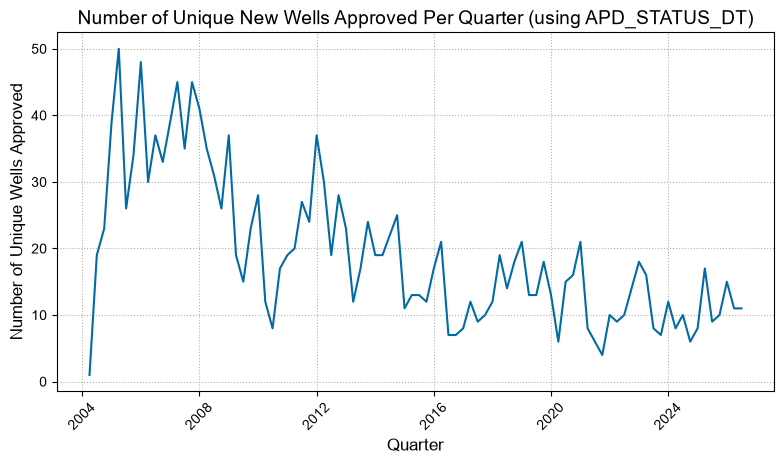

In [15]:
# Plot the number of approved new wells per quarter
plt.figure(figsize=(8, 8*.6))
plt.plot(wells_per_quarter_df['Approved_Quarter'], 
         wells_per_quarter_df['Number of Wells'])
plt.title('Number of Unique New Wells Approved Per Quarter (using APD_STATUS_DT)')
plt.xlabel('Quarter')
plt.ylabel('Number of Unique Wells Approved')
plt.grid(True)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

<small>*Number of distinct new-well approvals per quarter, full history, using `APD_master`.*</small>

The decline is structural, not a recent blip, though its true magnitude is smaller than a naive permit count would suggest: quarterly New Well approvals, counted by **distinct well**, peaked around 2005–2007 at roughly 26–50 wells per quarter (mean ~38) and now run at roughly 3–17 per quarter (mean ~10 over the last three) — a decline of about **75%** from peak. A raw count of permit *records* (rather than distinct wells) would show a steeper ~88% decline, because a single well could carry 2–3 separate "New Well" permit records in the mid-2000s peak years, a duplication rate that has fallen to roughly 1:1 in recent years — so part of the apparent historical peak was record-keeping volume, not drilling volume. The next chart breaks this corrected trend down by active operator and rig count, to test whether the decline reflects fewer participants remaining active or each participant simply drilling less.


In [16]:
import numpy as np

# Ensure approved_wells is up-to-date and has 'Approved_Quarter'
# This re-creates it for independence, ensuring 'Approved_Quarter' is a Period.
# Same 2004 cutoff as above (excludes a handful of sparse 1996-2003 legacy records).
approved_wells = APD_master[
    (APD_master['PERMIT_TYPE'] == 'New Well') & 
    (APD_master['APD_STATUS_DT'] >= '2004-01-01')].copy()
approved_wells['Approved_Quarter'] = approved_wells['APD_STATUS_DT'].dt.to_period('Q')

# 1. Calculate unique operators per quarter
operators_per_quarter = approved_wells.groupby('Approved_Quarter')['BUS_ASC_NAME'].nunique().reset_index()
operators_per_quarter.columns = ['Approved_Quarter', 'Number of Operators']
operators_per_quarter['Approved_Quarter'] = operators_per_quarter['Approved_Quarter'].dt.to_timestamp() # Convert to timestamp for merging

# 2. Calculate unique rigs per quarter (excluding NaN RIG_ID_NUM)
rigs_per_quarter = approved_wells[approved_wells['RIG_ID_NUM'].notna()].groupby('Approved_Quarter')['RIG_ID_NUM'].nunique().reset_index()
rigs_per_quarter.columns = ['Approved_Quarter', 'Number of Rigs']
rigs_per_quarter['Approved_Quarter'] = rigs_per_quarter['Approved_Quarter'].dt.to_timestamp() # Convert to timestamp for merging

# 3. Use wells_per_quarter_df (already available from previous steps) as 'Number of Wells'
# Ensure its 'Approved_Quarter' is also datetime for consistent merging
# (Assuming wells_per_quarter_df['Approved_Quarter'] is already datetime type)

# Merge dataframes
merged_ratios_df = pd.merge(wells_per_quarter_df, operators_per_quarter, on='Approved_Quarter', how='left')
merged_ratios_df = pd.merge(merged_ratios_df, rigs_per_quarter, on='Approved_Quarter', how='left')

# Fill NaN values with 0 for operators/rigs in quarters where no unique ones were identified
merged_ratios_df['Number of Operators'] = merged_ratios_df['Number of Operators'].fillna(0)
merged_ratios_df['Number of Rigs'] = merged_ratios_df['Number of Rigs'].fillna(0)

# Function to safely divide, handling division by zero
def safe_divide(numerator, denominator):
    return np.where(denominator > 0, numerator / denominator, 0)

# 4. Calculate the ratios, handling division by zero. 'Number of Wells' is
# now a distinct-well count (see the cell above), so these are genuinely
# wells-per-operator / wells-per-rig, not permits-per-operator/rig.
merged_ratios_df['Wells_per_Operator'] = safe_divide(merged_ratios_df['Number of Wells'], merged_ratios_df['Number of Operators'])
merged_ratios_df['Wells_per_Rig'] = safe_divide(merged_ratios_df['Number of Wells'], merged_ratios_df['Number of Rigs'])

In [17]:
def combined_legend(lns, ax, loc):
    # Combine legends
    # lns = [ln1, ln2]
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, bbox_to_anchor=loc, loc='upper left', fontsize=10)
    return lns, labs

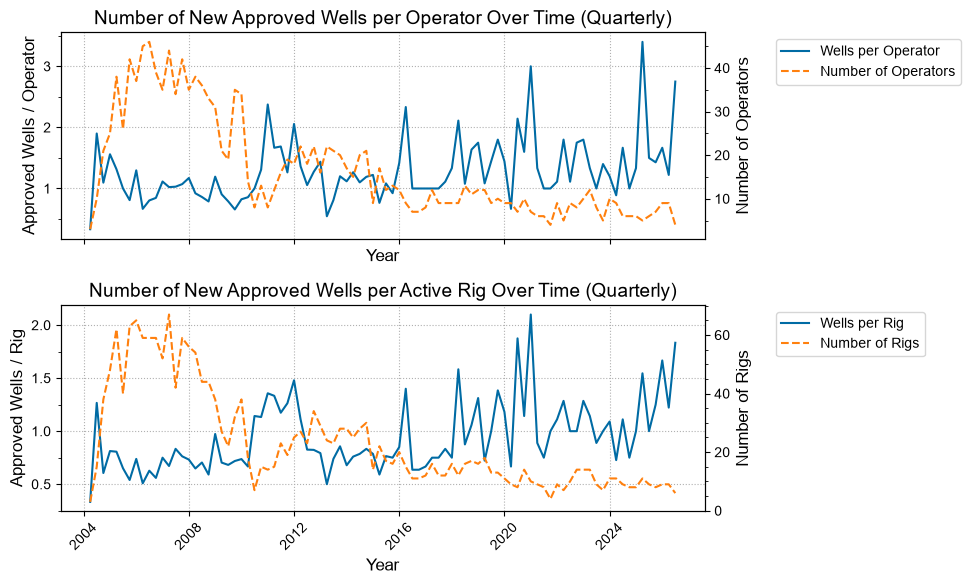

In [18]:
# Visualize the ratios over time, with two subplots: one for Permits per Operator and one for Permits per Rig.
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot 1: Permits per Operator
ln1 = axes[0].plot(merged_ratios_df['Approved_Quarter'], 
                   merged_ratios_df['Wells_per_Operator'],
                   color=colors[0],
                   label='Wells per Operator')
axes[0].set_title('Number of New Approved Wells per Operator Over Time (Quarterly)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Approved Wells / Operator')
axes[0].grid(True)
# axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_locator(MultipleLocator(1))  # Main ticks every 1 units
axes[0].yaxis.set_minor_locator(MultipleLocator(.5))  # Main ticks every 0.5 units

ax11 = axes[0].twinx()
ln2 = ax11.plot(merged_ratios_df['Approved_Quarter'], 
                merged_ratios_df['Number of Operators'], 
                color=colors[1], linestyle='--', 
                label='Number of Operators')
ax11.set_ylabel('Number of Operators')
# ax11.tick_params(axis='y', labelcolor=colors[1])
ax11.grid(False)  # Disable grid for the secondary y-axis
ax11.yaxis.set_major_locator(MultipleLocator(10))
ax11.yaxis.set_minor_locator(MultipleLocator(5))
lns = ln1 + ln2
combined_legend(lns, 
                axes[0], 
                loc=(1.1, 1))  # Position legend outside the plot area

# Plot 2: Permits per Rig
ln3 = axes[1].plot(merged_ratios_df['Approved_Quarter'],
                   merged_ratios_df['Wells_per_Rig'],
                   color=colors[0],
                   label='Wells per Rig')
axes[1].set_title('Number of New Approved Wells per Active Rig Over Time (Quarterly)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Approved Wells / Rig')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_locator(MultipleLocator(.5))
axes[1].yaxis.set_minor_locator(MultipleLocator(.25))

ax22 = axes[1].twinx()
ln4 = ax22.plot(merged_ratios_df['Approved_Quarter'], 
                merged_ratios_df['Number of Rigs'], 
                color=colors[1], linestyle='--',
                label='Number of Rigs')
ax22.set_ylabel('Number of Rigs')
# ax22.tick_params(axis='y', labelcolor=colors[1])
ax22.grid(False)  # Disable grid for the secondary y-axis
ax22.yaxis.set_major_locator(MultipleLocator(20))
ax22.yaxis.set_minor_locator(MultipleLocator(5))
lns = ln3 + ln4
combined_legend(lns, 
                axes[1], 
                loc=(1.1, 1))  # Position legend outside the plot area

plt.tight_layout()
plt.show()

<small>*Distinct new wells approved per active operator and per active rig, by quarter, full history.*</small>

Wells-per-operator and wells-per-rig have stayed comparatively low and stable over the full history (median ~1.1 wells per operator and ~0.8 wells per rig per quarter, rarely exceeding 2–3) even as the raw number of active operators and rigs fell sharply — from a mid-2000s peak of 46 operators and 67 rigs down to single digits in the most recent quarters. In other words, the ~75% decline in distinct wells shown above is driven mainly by **fewer operators and rigs remaining active in the Gulf of Mexico at all**, not by each remaining participant individually drilling fewer wells — a materially different story for market-sizing purposes than a uniform slowdown would be. We finally visualize the same full timeline segmented by **permit type**, to see whether the mix of permit types has shifted alongside this decline.


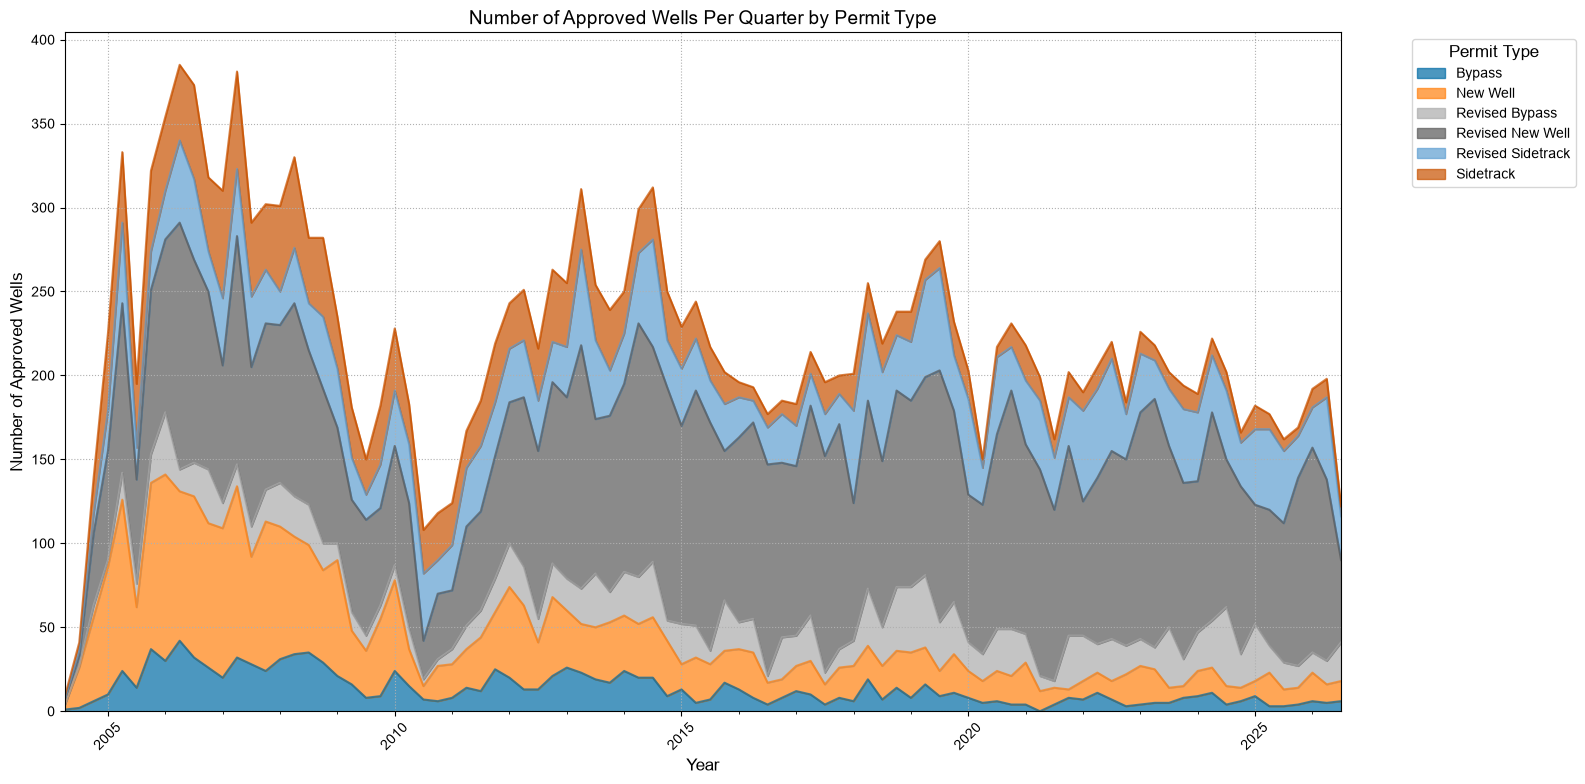

In [19]:
# Unlike the New-Well-only filter used above, this reverts to *all* permit
# types (re-running independently for clarity) to see how the permit-type
# mix itself has shifted over the full history. Same 2004 cutoff as above.
approved_wells = APD_master[APD_master['APD_STATUS_DT'] >= '2004-01-01'].copy()

# Extract the year and quarter from the 'APD_STATUS_DT'
approved_wells['Approved_Quarter'] = approved_wells['APD_STATUS_DT'].dt.to_period('Q')

# Group by quarter and permit type, then count the wells
wells_per_quarter_permit = approved_wells.groupby(['Approved_Quarter', 'PERMIT_TYPE']).size().unstack(fill_value=0)

# Convert the PeriodIndex to datetime for plotting
wells_per_quarter_permit.index = wells_per_quarter_permit.index.to_timestamp()

# Note: .plot() creates its own figure, so no separate plt.figure() call is
# needed here -- calling both (as before) produced two figures, the first blank.
wells_per_quarter_permit.plot(kind='area', stacked=True, figsize=(16, 8), alpha=0.7)
plt.title('Number of Approved Wells Per Quarter by Permit Type')
plt.xlabel('Year')
plt.ylabel('Number of Approved Wells')
plt.grid(True)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.legend(title='Permit Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


<small>*Number of approved wells per quarter, stacked by permit type, full history.*</small>

The mix has shifted toward revision-based permits over time: in the most recent four quarters, `Revised New Well` alone accounts for roughly 59% of all approvals, while genuinely original permit types (`New Well`, `Sidetrack`, `Bypass` — non-revised) together make up only about 14%. This is consistent with both the New-Well-only cut earlier in §5.1 (only 7% of the current 12-month window's permits are genuinely new wells) and with §5.4's finding that revised permit types clear far faster than original ones: today's approval mix is dominated by the category that also has the shortest regulatory turnaround. With this longer-term backdrop established, the remainder of this section narrows to the most recent 12 months.


In [20]:
# import requests
# APD Raw Data download link, from BSEE's Raw Data site
url = 'https://www.data.bsee.gov/Production/Files/OffshoreStatsRawData.zip'
destination = 'OffshoreStatsRawData.zip'

response = requests.get(url)
if response.status_code == 200:
    with open(destination, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded '{destination}' successfully.")
else:
    print(f"Failed to download file. Status code: {response.status_code}")

Downloaded 'OffshoreStatsRawData.zip' successfully.


In [21]:
# import zipfile
# import os

zip_file_path = destination      # The downloaded file
extract_dir = 'OffshoreStatsRawData'  # Directory to unzip data

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted contents of '{zip_file_path}' to '{extract_dir}'.")

Extracted contents of 'OffshoreStatsRawData.zip' to 'OffshoreStatsRawData'.


In [22]:
# import pandas as pd
# import numpy as np

# Load APD data
OSWD = pd.read_csv("./OffshoreStatsRawData/OffshoreStatsRawData/mv_sbwd_wells2.txt",
                  encoding='latin1',
                  low_memory=False)
OSWD['WELL_SPUD_DATE'] = pd.to_datetime(OSWD['WELL_SPUD_DATE'], errors='coerce')
OSWD.sort_values(by='WELL_SPUD_DATE', inplace=True)
# Mask values to only after 2004-01-01, to match APD dataset
OSWD = OSWD[OSWD['WELL_SPUD_DATE'] >= '2004-01-01'].copy()
# Summarize entries by quarter, to compare to previous APD dataset
OSWD['Spud_Quarter'] = OSWD['WELL_SPUD_DATE'].dt.to_period('Q')
OSWD.head()
OSWD.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7224 entries, 35341 to 28436
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   WATER_DEPTH      7224 non-null   float64       
 1   API_WELL_NUMBER  7224 non-null   int64         
 2   WELL_SPUD_DATE   7224 non-null   datetime64[ns]
 3   Spud_Quarter     7224 non-null   period[Q-DEC] 
dtypes: datetime64[ns](1), float64(1), int64(1), period[Q-DEC](1)
memory usage: 282.2 KB


In [23]:
# Drop duplicate wells based on API_WELL_NUMBER, to ensure each well is only counted once in the analysis.
# Shape before drop
print(f'Shape before drop: {OSWD.shape[0]}')
OSWD.drop_duplicates(subset=['API_WELL_NUMBER'], inplace=True)
# Shape after drop
print(f'Shape after drop: {OSWD.shape[0]}')

Shape before drop: 7224
Shape after drop: 7224


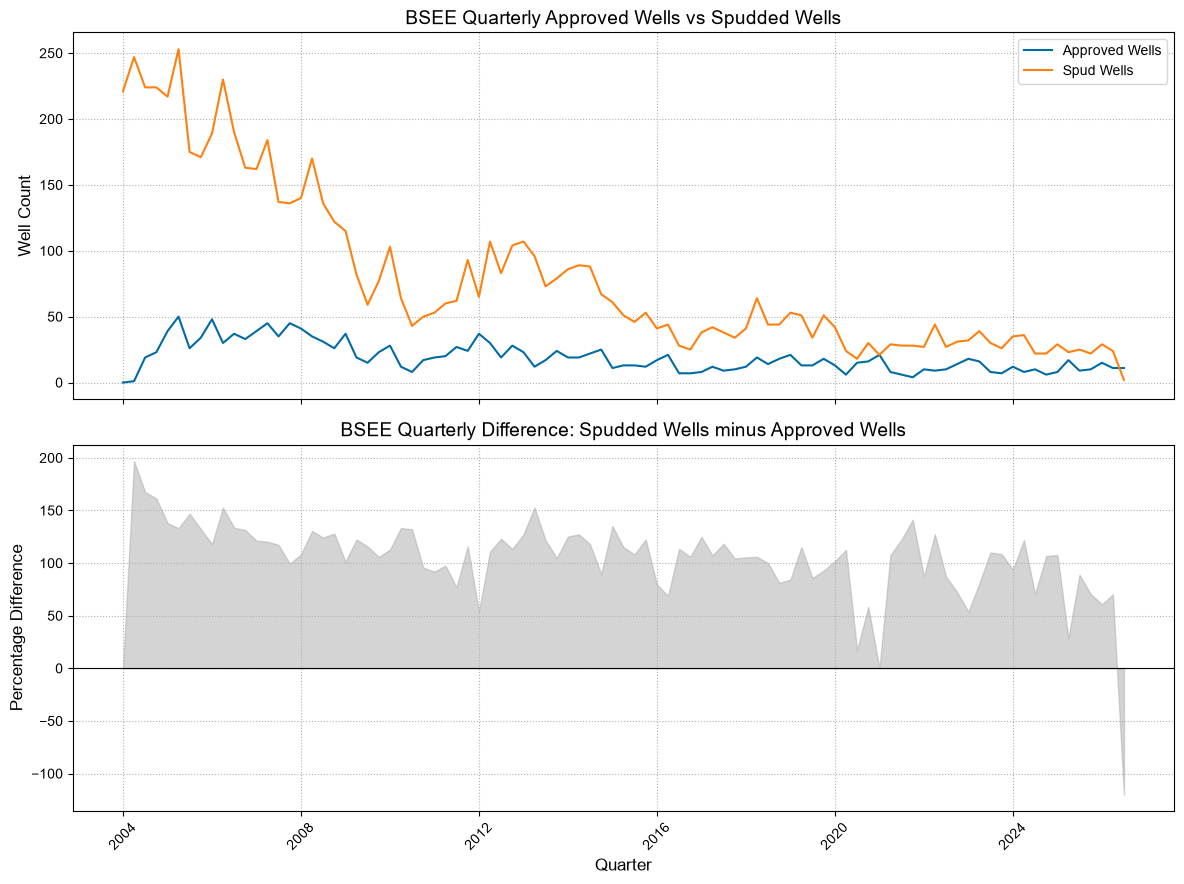

In [24]:
# Build quarter-level comparison between APD approvals and OSWD spud counts.
# oswd_quarterly = OSWD.groupby('Spud_Quarter').size().reset_index(name='Spud_Well_Count')
oswd_quarterly = OSWD.groupby('Spud_Quarter')['API_WELL_NUMBER'].nunique().reset_index(name='Spud_Well_Count')
oswd_quarterly['Approved_Quarter'] = oswd_quarterly['Spud_Quarter'].dt.to_timestamp()

merged_quarterly = pd.merge(
    wells_per_quarter_df,
    oswd_quarterly[['Approved_Quarter', 'Spud_Well_Count']],
    on='Approved_Quarter',
    how='outer'
).sort_values('Approved_Quarter').fillna(0)

merged_quarterly['Difference'] = merged_quarterly['Spud_Well_Count'] - merged_quarterly['Number of Wells']

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].plot(
    merged_quarterly['Approved_Quarter'],
    merged_quarterly['Number of Wells'],
    label='Approved Wells',
    color=colors[0]
)
axes[0].plot(
    merged_quarterly['Approved_Quarter'],
    merged_quarterly['Spud_Well_Count'],
    label='Spud Wells',
    color=colors[1]
)
axes[0].set_title('BSEE Quarterly Approved Wells vs Spudded Wells')
axes[0].set_ylabel('Well Count')
axes[0].legend()
axes[0].grid(True)

percentage_difference = np.where(
    merged_quarterly['Number of Wells'] > 0,
    merged_quarterly['Difference'] / (1+(merged_quarterly['Number of Wells']+merged_quarterly['Spud_Well_Count'])/2) * 100,
    0
)
axes[1].stackplot(
    merged_quarterly['Approved_Quarter'],
    percentage_difference,
    color=colors[2], alpha = .5
)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('BSEE Quarterly Difference: Spudded Wells minus Approved Wells')
axes[1].set_ylabel('Percentage Difference')
axes[1].set_xlabel('Quarter')
axes[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.1 — Operator-Level Activity and Water-Depth Exposure

As a first cut, §5.1 quantifies unique well activity and average water depth by operator, using the operator field (`BUS_ASC_NAME`) as the grouping key. The objective is to establish, at a glance, which companies are driving current permitting volume and the water-depth regime each typically operates in — a baseline that later sections build on.


In [25]:
# Shared table-styling helper for this section: applies a blue-red
# conditional-formatting color scale (matplotlib's diverging 'coolwarm'
# colormap) per column, computed on the real numeric values, with the
# display formatting (e.g. thousands separators) applied afterward via
# Styler.format() so formatting never breaks the underlying gradient calc.
def style_table(df, subset=None, formats=None, cmap='coolwarm'):
    styler = df.style.background_gradient(cmap=cmap, subset=subset)
    if formats:
        styler = styler.format(formats)
    return styler

In [26]:
# Aggregate by operator (BUS_ASC_NAME) to quantify which companies drive
# current permitting volume, and their typical water-depth exposure --
# a proxy for shelf vs. deepwater operational focus per company.
unique_wells_by_company = APD.groupby('BUS_ASC_NAME').agg(
    Unique_Well_Name_Count=('WELL_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean')
).reset_index()
# Rank operators by permitting volume, most active first
unique_wells_by_company = unique_wells_by_company.sort_values(by='Unique_Well_Name_Count', ascending=False).reset_index(drop=True)
# Rename columns for better display
unique_wells_by_company.columns = ['Company_Name', 'Unique_Well_Name_Count', 'Mean_Water_Depth']

# Color-scale the two numeric columns independently (blue = low, red = high
# per column); thousands-separator formatting is applied at display time
# only, so it doesn't interfere with the gradient's underlying numeric calc.
display(style_table(
    unique_wells_by_company,
    subset=['Unique_Well_Name_Count', 'Mean_Water_Depth'],
    formats={'Mean_Water_Depth': '{:,.0f}'}
))

,Company_Name,Unique_Well_Name_Count,Mean_Water_Depth
0,Shell Offshore Inc.,32,"6,058"
1,"Arena Offshore, LP",29,188
2,BP Exploration & Production Inc.,17,"5,632"
3,"Cantium, LLC",10,56
4,Anadarko Petroleum Corporation,7,"5,599"
5,Chevron U.S.A. Inc.,7,"4,927"
6,"LLOG Exploration Offshore, L.L.C.",4,"4,367"
7,Murphy Exploration & Production Company - USA,3,"7,206"
8,"Beacon Growthco Operating Company, L.L.C.",2,"4,346"
9,Union Oil Company of California,2,"7,037"


Shell Offshore and Arena Offshore account for the largest share of unique wells in the trailing 12 months, but at markedly different water depths — Shell's activity clusters in deepwater (Mean Water Depth in the thousands of feet), while Arena's is concentrated on the shelf (well under 200 ft). 

This operator-level split is directly relevant to rig-class demand and MPD applicability: deepwater-focused operators draw on a different rig pool (and carry different well-control considerations) than shelf-focused ones, a distinction §5.2 and §5.3 examine directly.

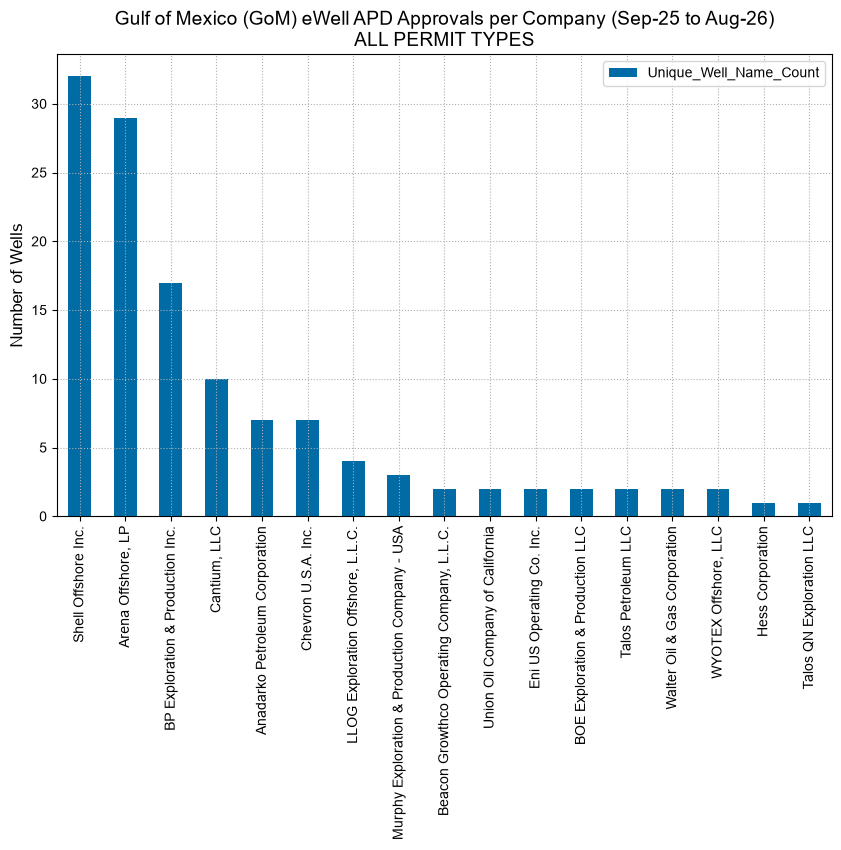

In [27]:
dynamic_title = f'Gulf of Mexico (GoM) eWell APD Approvals per Company ({date_min} to {date_max})\nALL PERMIT TYPES'
# Visualize permitting-volume ranking from the table above, so relative
# operator activity is legible without scanning the raw counts.
ax = unique_wells_by_company[['Company_Name', 'Unique_Well_Name_Count']].plot(kind='bar', figsize=[10,10*.6])
ax.set_xticklabels([company for company in unique_wells_by_company['Company_Name'].values])
ax.set_title(dynamic_title)
ax.set_ylabel('Number of Wells')
plt.show()

<small>*Number of unique BSEE-approved APDs per operator in the Gulf of Mexico over the trailing 12 months.*</small>

The chart makes the same ranking visible without requiring a reader to scan the table's raw counts — useful shorthand when this analysis is presented alongside operator-level business discussions (e.g., competitive-activity reviews or partner due diligence).

We now center the analysis only on the **'new well'** permits - i.e., where PERMIT_TYPE is set to **'New Well'**. These permits reflect more closely the drilling activity of each operator, since the previous analysis includes all permit types revealed on the code line below.

In [28]:
# Inspect the unique values in the PERMIT_TYPE column to understand the types of permits present in the dataset.
print(f'Permit types present on the dataset: {APD["PERMIT_TYPE"].unique().tolist()}')

Permit types present on the dataset: ['Revised New Well', 'New Well', 'Bypass', 'Revised Bypass', 'Sidetrack', 'Revised Sidetrack']


In [29]:
# Repeat the §5.1 aggregation, restricted to PERMIT_TYPE == 'New Well' --
# i.e. genuinely new drilling, excluding sidetrack/bypass revisions to
# already-permitted wells -- to see how much the ranking above changes.
new_well_mask = (APD['PERMIT_TYPE'] == 'New Well') # wells where APD type is NEW
unique_new_wells_by_company = APD[new_well_mask].groupby('BUS_ASC_NAME').agg(
    Unique_Well_Name_Count=('WELL_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean')
).reset_index()
unique_new_wells_by_company.rename(columns={'Unique_Well_Name_Count': 'Unique_New_Well_Name_Count'}, inplace=True)
# Rank operators by permitting volume, most active first
unique_new_wells_by_company = unique_new_wells_by_company.sort_values(by='Unique_New_Well_Name_Count', ascending=False).reset_index(drop=True)
# Rename columns for better display
unique_new_wells_by_company.columns = ['Company_Name', 'Unique_New_Well_Name_Count', 'Mean_Water_Depth']

# Color-scale the two numeric columns independently (blue = low, red = high
# per column); thousands-separator formatting is applied at display time
# only, so it doesn't interfere with the gradient's underlying numeric calc.
display(style_table(
    unique_new_wells_by_company,
    subset=['Unique_New_Well_Name_Count', 'Mean_Water_Depth'],
    formats={'Mean_Water_Depth': '{:,.0f}'}
))

,Company_Name,Unique_New_Well_Name_Count,Mean_Water_Depth
0,Shell Offshore Inc.,17,"6,276"
1,BP Exploration & Production Inc.,12,"6,165"
2,Anadarko Petroleum Corporation,5,"5,254"
3,"Arena Offshore, LP",3,197
4,Murphy Exploration & Production Company - USA,3,"6,974"
5,Chevron U.S.A. Inc.,3,"4,752"
6,"WYOTEX Offshore, LLC",2,114
7,BOE Exploration & Production LLC,2,"6,366"
8,"LLOG Exploration Offshore, L.L.C.",2,"6,172"
9,Union Oil Company of California,2,"7,037"


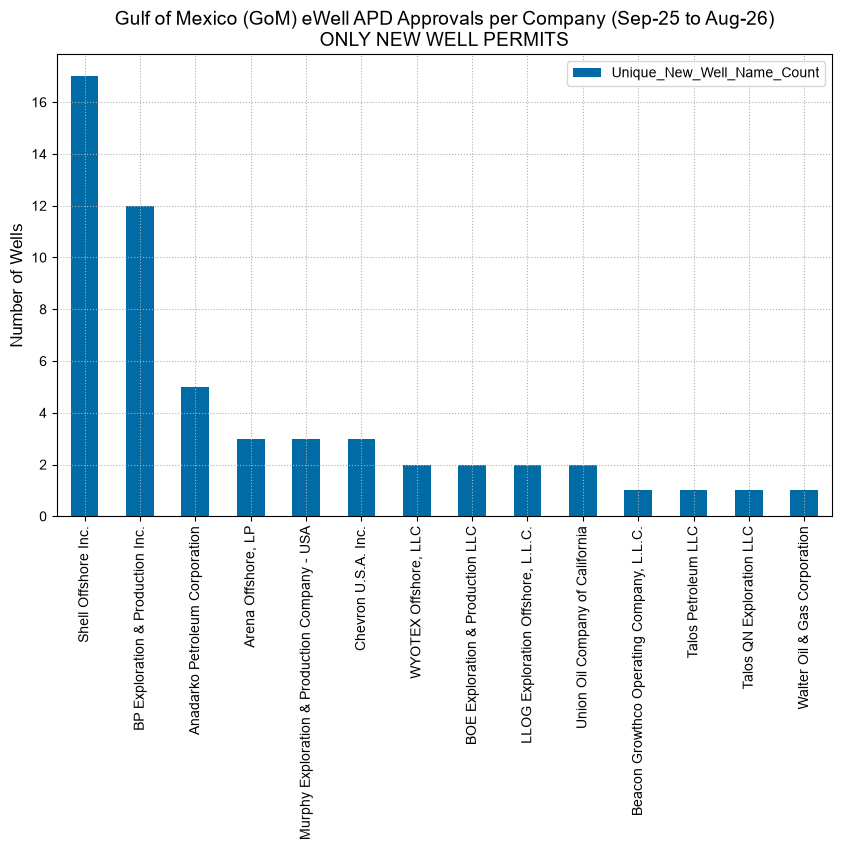

In [30]:
dynamic_title = f'Gulf of Mexico (GoM) eWell APD Approvals per Company ({date_min} to {date_max})\nONLY NEW WELL PERMITS'
# Visualize the New-Well-only ranking from the table above, for direct
# visual comparison against the all-permit-types chart earlier in §5.1.
ax = unique_new_wells_by_company[['Company_Name', 'Unique_New_Well_Name_Count']].plot(kind='bar', figsize=[10,10*.6])
ax.set_xticklabels([company for company in unique_new_wells_by_company['Company_Name'].values])
ax.set_title(dynamic_title)
ax.set_ylabel('Number of Wells')
plt.show()

<small>*Number of genuinely new-well APD approvals per operator in the Gulf of Mexico over the trailing 12 months (excludes sidetrack/bypass revisions).*</small>

Restricting to `PERMIT_TYPE == 'New Well'` narrows the picture sharply: only 51 of the 727 permits in this window (7%) are genuinely new wells rather than revisions to already-permitted wells. The ranking reshuffles accordingly — Shell Offshore still leads (15 new wells), but Arena Offshore, LP, the #2 operator by total permit count in the all-permit-types view above (28), drops to a tie for 5th with only 3 genuinely new wells, since most of its activity there consists of revisions. This distinction matters for reading the rest of this section: the all-permit-types counts used from §5.2 onward mostly reflect *ongoing work on existing wells*, not fresh drilling.


### 5.2 Rig Type Summary

Operator-level activity is only half of the planning picture — the rig classes actually performing the work determine near-term equipment availability and the prevalence of deepwater vs. shelf drilling programs. This subsection re-aggregates the same 12-month dataset by rig type (`RIG_TYPE_CODE`), computing the number of distinct rigs and the mean water depth associated with each class. The objective is to establish whether current APD approvals lean on a narrow set of rig classes (e.g., predominantly drillships) or a diversified fleet mix — a signal directly relevant to rig-market tightness and day-rate exposure.

In [31]:
# Aggregate by rig type (RIG_TYPE_CODE) to quantify fleet diversity and
# the water-depth regime each rig class is actually operating in.
unique_rig_info_by_type = APD.groupby('RIG_TYPE_CODE').agg(
                              Unique_RIG_NAME_Count=('RIG_NAME', 'nunique'),
                              Mean_Water_Depth=('WATER_DEPTH', 'mean')
                          ).reset_index()
# Rank rig classes by count of distinct rigs, most active first
unique_rig_info_by_type = unique_rig_info_by_type.sort_values(by='Unique_RIG_NAME_Count', ascending=False).reset_index(drop=True)
# Rename columns for better display
unique_rig_info_by_type.columns = ['Rig_Type_Code', 'Unique_RIG_NAME_Count', 'Mean_Water_Depth']

display(style_table(
    unique_rig_info_by_type,
    subset=['Unique_RIG_NAME_Count', 'Mean_Water_Depth'],
    formats={'Mean_Water_Depth': '{:,.0f}'}
))

,Rig_Type_Code,Unique_RIG_NAME_Count,Mean_Water_Depth
0,DRILLSHIP,19,"5,683"
1,PLATFORM,9,"4,724"
2,JACKUP,5,146
3,DP SEMISUBMERSIBLE,1,"1,483"


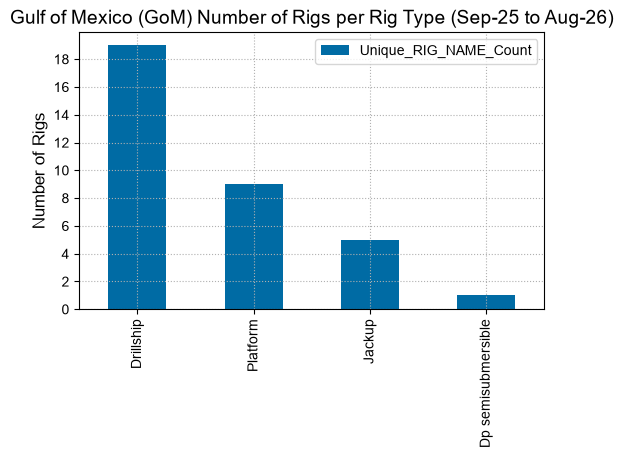

In [32]:
import matplotlib.ticker as ticker

dynamic_title = f'Gulf of Mexico (GoM) Number of Rigs per Rig Type ({date_min} to {date_max})'
# Visualize fleet-class distribution from the table above.
ax = unique_rig_info_by_type[['Rig_Type_Code', 'Unique_RIG_NAME_Count']].plot(kind='bar', figsize=[6,6*.6])
ax.set_xticklabels([rig.lower().capitalize() for rig in unique_rig_info_by_type['Rig_Type_Code'].values])
ax.set_title(dynamic_title)
ax.set_ylabel('Number of Rigs')
# Force the y-axis to use integer labels
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.show()

<small>*Number of unique rigs by rig type associated with BSEE-approved APDs in the Gulf of Mexico over the trailing 12 months.*</small>

Drillships dominate the current rig count and, consistent with §5.1's water-depth split, operate in the deepest average water depth of the four classes — jackups sit at the opposite extreme, consistent with shelf-focused operators like Arena Offshore. Read together with the operator-level view, this indicates current permitting activity is not evenly spread across rig classes: it skews toward deepwater floater capacity, a relevant signal for near-term rig availability and day-rate exposure in that segment.

The table and chart above summarize water depth with a single number (the mean) per rig type — useful for ranking, but it hides how much each rig class's depth range actually varies. The combined violin/boxplot below shows the full distribution instead.

In [33]:

from matplotlib.ticker import FuncFormatter


def format_thousands(ax):
    ax.get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
    return

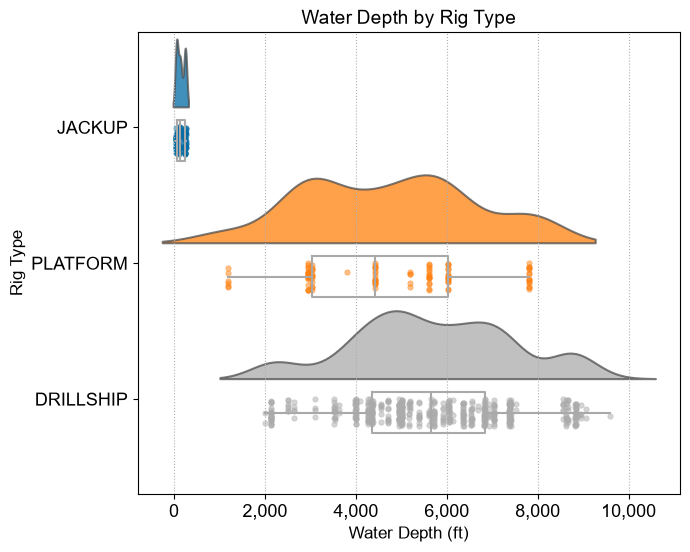

In [34]:
# example taken from https://python-graph-gallery.com/raincloud-plot-with-matplotlib-and-ptitprince/
import ptitprince as pt

# Drop DP SEMISUBMERSIBLE rig type, which has only 1 well in the dataset
rig_type_mask = APD['RIG_TYPE_CODE'] != 'DP SEMISUBMERSIBLE'
APD_rigs = APD[rig_type_mask]

# The style of the line that represents the median.
medianprops = {"linewidth": 1.5, "color": "#a9a9a9", "solid_capstyle": "butt"}
# The style of the box ... This is also used for the whiskers
boxprops = {"linewidth": 1.5, "color": "#a9a9a9"}

rig_type_order = APD_rigs.groupby('RIG_TYPE_CODE')['WATER_DEPTH'].median().sort_values().index.tolist()
COLORS = colors[:len(rig_type_order)]  # Use the same color palette as before
# Create our own Axes with custom size
fig, ax = plt.subplots(figsize=(7, 6))

# inner=None removes the default boxplot
# The 'width' argument allows us to scale the density
# We pass our color palette in the 'palette' argument
pt.half_violinplot(
    x="WATER_DEPTH", 
    y="RIG_TYPE_CODE", 
    palette=COLORS, alpha = 0.75,
    inner=None, data=APD_rigs,  ax=ax,
    # scale='width' instead rescales every
    # violin to reach the same max bulge, so the flatter rig types get
    # real body too. width bumped up from the 0.8 default for a taller bulge.
    scale='width',
    width=1.0,
    order=rig_type_order
);

# Pad the y-limits outward to give them room.
y0, y1 = ax.get_ylim()
pad = 0.2
if y0 < y1:
    ax.set_ylim(y0 - pad, y1 + pad)
else:
    ax.set_ylim(y0 + pad, y1 - pad)

# # Iterate over the rig_types
for i, rig_type in enumerate(rig_type_order):
    # Subset the data
    data = APD_rigs[APD_rigs["RIG_TYPE_CODE"] == rig_type]
    
    # Jitter the values on the vertical axis
    y = i + np.random.uniform(high=0.2, size=len(data))
    
    # Select the values of the horizontal axis
    x = data["WATER_DEPTH"]
    
    # Add the rigs using the scatter method.
    ax.scatter(x, y, color=COLORS[i], alpha=0.5, s=15, edgecolor=None, linewidth=0.5)

# Generate list of arrays
boxplot_data = [
    APD_rigs[APD_rigs["RIG_TYPE_CODE"] == rig_type]["WATER_DEPTH"].values 
    for rig_type in rig_type_order
]

# Vertical positions for the boxplots
POSITIONS = [0, 1, 2, 3]

# Positions are shifted now
SHIFT = 0.1
POSITIONS = [0 + SHIFT, 1 + SHIFT, 2 + SHIFT]

ax.boxplot(
    boxplot_data, 
    orientation='horizontal',
    positions=POSITIONS, 
    manage_ticks=False,
    showfliers = False, # Do not show the outliers beyond the caps.
    showcaps = False,   # Do not show the caps
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops,
)

# Finally, add labels and a title
ax.set_xlabel("Water Depth (ft)")
ax.set_ylabel("Rig Type")
ax.set_title("Water Depth by Rig Type")
format_thousands(ax)  # Format y-axis labels with thousands separator

# Change size of tick labels
ax.tick_params(labelsize=13)

plt.show()

<small>*Water depth distribution by rig type (boxes show the interquartile range and median; whiskers extend to the full observed range, none of the four classes have statistical outliers by the 1.5×IQR rule).*</small>

Jackups occupy a clearly separate shallow band (44–253 ft, median 138 ft) with no overlap into the other three classes — confirming rig type alone is a reliable shallow-vs-not signal at that end. 

The `DP SEMISUBMERSIBLE` class is excluded, since it shows zero spread (all 7 records sit at exactly 1,483 ft) — with only 7 wells in this class, that's a single operational context repeated across records, not a general pattern, and shouldn't be read as "DP semisubmersibles always drill at ~1,483 ft." 

More notably, platforms (1,186–7,821 ft) and drillships (2,009–9,589 ft) overlap substantially across most of their range — so beyond the jackup/floater split, rig type by itself is a weaker predictor of exact water depth than the §5.2 mean-only table might suggest; the specific rig class matters less than the specific well within it.

### 5.3 Rigs per Operator Summary

§5.1 and §5.2 each aggregate along a single dimension — operator, then rig class — but neither shows how the two intersect. This subsection closes that gap: first by re-aggregating to count distinct rigs per operator, then by cross-tabulating operator against rig type directly, producing a company × rig-class matrix. The objective is to identify which operators concentrate their activity on a single rig class (a narrower operational/contracting footprint) versus those running a diversified fleet mix across classes — information relevant to contracting strategy and rig-market exposure at the company level.

In [35]:
# Aggregate by operator again, this time counting distinct rigs (rather
# than wells) -- a company drilling many wells with one rig reads very
# differently, operationally, than one running many rigs concurrently.
unique_wells_by_company = APD.groupby('BUS_ASC_NAME').agg(
    Unique_Rig_Name_Count=('RIG_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean')
).reset_index()
# Rank operators by number of distinct rigs deployed, most first
unique_wells_by_company = unique_wells_by_company.sort_values(by='Unique_Rig_Name_Count', ascending=False).reset_index(drop=True)
# Rename columns for better display
unique_wells_by_company.columns = ['Company_Name', 'Unique_Rig_Name_Count', 'Mean_Water_Depth']

display(style_table(
    unique_wells_by_company,
    subset=['Unique_Rig_Name_Count', 'Mean_Water_Depth'],
    formats={'Mean_Water_Depth': '{:,.0f}'}
))

,Company_Name,Unique_Rig_Name_Count,Mean_Water_Depth
0,Shell Offshore Inc.,10,"6,058"
1,BP Exploration & Production Inc.,5,"5,632"
2,Chevron U.S.A. Inc.,4,"4,927"
3,"Arena Offshore, LP",4,188
4,Walter Oil & Gas Corporation,3,"1,858"
5,Anadarko Petroleum Corporation,2,"5,599"
6,"Beacon Growthco Operating Company, L.L.C.",2,"4,346"
7,BOE Exploration & Production LLC,1,"6,364"
8,"Cantium, LLC",1,56
9,Hess Corporation,1,"2,507"


Ranking by rig count rather than well count reshuffles the leaderboard: Shell and BP lead on both metrics, but Walter Oil & Gas — a comparatively modest well-count operator in §5.1 — appears here running three distinct rigs, evidence of a broader concurrent operational footprint than raw well counts alone would suggest. The next table makes the operator × rig-class relationship explicit rather than inferred.

In [36]:
# Cross-tabulate operator against rig type directly (rather than each
# separately) to see the intersection: how many distinct rigs of each
# class each operator runs, and the mean water depth for that combination.
unique_wells_by_company = APD.groupby(['BUS_ASC_NAME','RIG_TYPE_CODE']).agg(
    Unique_Rig_Name_Count=('RIG_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean')
).reset_index()

display(style_table(
    unique_wells_by_company,
    subset=['Unique_Rig_Name_Count', 'Mean_Water_Depth'],
    formats={'Mean_Water_Depth': '{:,.1f}'}
))

,BUS_ASC_NAME,RIG_TYPE_CODE,Unique_Rig_Name_Count,Mean_Water_Depth
0,Anadarko Petroleum Corporation,DRILLSHIP,2,"5,598.8"
1,"Arena Offshore, LP",JACKUP,4,188.4
2,BOE Exploration & Production LLC,DRILLSHIP,1,"6,364.5"
3,BP Exploration & Production Inc.,DRILLSHIP,3,"5,775.8"
4,BP Exploration & Production Inc.,PLATFORM,2,"5,208.1"
5,"Beacon Growthco Operating Company, L.L.C.",DRILLSHIP,2,"4,346.1"
6,"Cantium, LLC",JACKUP,1,55.8
7,Chevron U.S.A. Inc.,DRILLSHIP,3,"4,907.0"
8,Chevron U.S.A. Inc.,PLATFORM,1,"5,189.0"
9,Eni US Operating Co. Inc.,PLATFORM,1,"5,610.0"


The long-format table above is exhaustive but not easy to scan — each operator/rig-type pair sits on its own row. Reshaping it into a wide company × rig-class matrix (a `pivot`) turns that same data into a single at-a-glance table, which is the more natural form for a fleet-composition or contracting-strategy discussion.

In [37]:
# Reshape the long-format cross-tab above into a wide company x rig-class
# matrix; missing operator/rig-type combinations become an explicit 0
# (no rigs of that class), rather than an absent row.
rig_count_by_company_and_type = unique_wells_by_company.pivot(
    index='BUS_ASC_NAME', columns='RIG_TYPE_CODE', values='Unique_Rig_Name_Count'
).fillna(0).astype(int)

display(style_table(rig_count_by_company_and_type))

RIG_TYPE_CODE,DP SEMISUBMERSIBLE,DRILLSHIP,JACKUP,PLATFORM
BUS_ASC_NAME,,,,
Anadarko Petroleum Corporation,0,2,0,0
"Arena Offshore, LP",0,0,4,0
BOE Exploration & Production LLC,0,1,0,0
BP Exploration & Production Inc.,0,3,0,2
"Beacon Growthco Operating Company, L.L.C.",0,2,0,0
"Cantium, LLC",0,0,1,0
Chevron U.S.A. Inc.,0,3,0,1
Eni US Operating Co. Inc.,0,0,0,1
Hess Corporation,0,1,0,0


The matrix confirms the concentration pattern already visible in §5.2's fleet-composition chart: most operators run a single rig class (mostly drillships), and only a handful — Shell, BP, Chevron, Walter Oil & Gas — split their activity across two or more classes. The stacked bar chart below renders this same matrix visually, ranked by total rig count per operator.

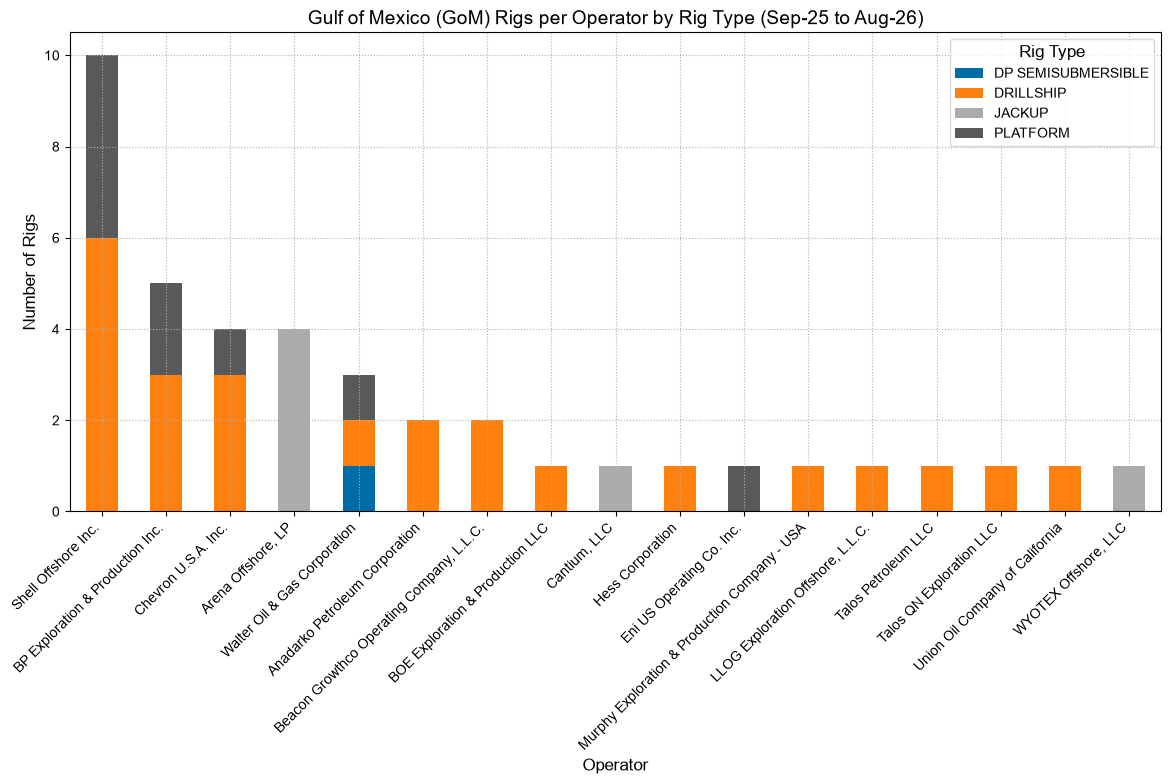

In [38]:
import matplotlib.pyplot as plt
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter
style.use('tableau-colorblind10')
#style.use('seaborn-notebook')
# style.use('seaborn-whitegrid')

# plt.rcParams['font.family'] = 'Times New Roman'
# mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['ps.fonttype'] = 42
# mpl.rcParams['font.family'] = 'Arial'
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Create the pivoted dataframe
pivoted = unique_wells_by_company.pivot(index='BUS_ASC_NAME', columns='RIG_TYPE_CODE', values='Unique_Rig_Name_Count').fillna(0).astype(int)

# Sort companies by total rigs descending
pivoted['Total'] = pivoted.sum(axis=1)
pivoted = pivoted.sort_values('Total', ascending=False).drop('Total', axis=1)

# Plot stacked bar
ax = pivoted.plot(kind='bar', stacked=True, figsize=(12, 8))
ax.set_title(f'Gulf of Mexico (GoM) Rigs per Operator by Rig Type ({date_min} to {date_max})')
ax.set_ylabel('Number of Rigs')
ax.set_xlabel('Operator')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rig Type')
plt.tight_layout()
plt.show()

<small>*Stacked bar chart showing the number of unique rigs by rig type for each operator associated with BSEE-approved APDs in the Gulf of Mexico over the trailing 12 months.*</small>

This closes the operator/rig-class view: §5.1–§5.3 establish *who* is drilling, with *what* equipment, and how those two dimensions intersect. The remaining two subsections shift from activity composition to process efficiency — first the regulatory approval cycle (§5.4), then equipment-to-well fit (§5.5).

### 5.4 Permit Approval Cycle Time by Permit Type

The analyses so far describe drilling activity itself; this one describes the regulatory process that gates it. Every APD record carries both a submission timestamp (`APD_SUB_STATUS_DT`) and a BSEE approval timestamp (`APD_STATUS_DT`); their difference is the approval cycle time — how long a permit sat in queue before being cleared to drill. The objective is to quantify that turnaround by `PERMIT_TYPE`, since a **new well** permit and a **revised sidetrack/bypass** on an already-permitted well are, in practice, very different regulatory reviews. This is a direct lead-time input for scheduling a drilling or MPD campaign: knowing the typical (and worst-case) turnaround by permit type tells an operator how far ahead of a target spud date a given permit type should be filed.

In [39]:
# Approval cycle time in days: time from submission to BSEE approval.
APD['Turnaround_Days'] = (APD['APD_STATUS_DT'] - APD['APD_SUB_STATUS_DT']).dt.total_seconds() / 86400

# Aggregate by permit type. The distribution is heavily right-skewed (a
# handful of permits take months while most clear in under a day), so the
# median -- not just the mean -- is reported as the representative figure;
# mean and max are retained for context on the tail risk.
turnaround_by_permit_type = APD.groupby('PERMIT_TYPE').agg(
    Median_Turnaround_Days=('Turnaround_Days', 'median'),
    Mean_Turnaround_Days=('Turnaround_Days', 'mean'),
    Max_Turnaround_Days=('Turnaround_Days', 'max'),
    Permit_Count=('Turnaround_Days', 'count')
).reset_index()
# Rank permit types from fastest- to slowest-clearing, by median
turnaround_by_permit_type = turnaround_by_permit_type.sort_values('Median_Turnaround_Days').reset_index(drop=True)
turnaround_by_permit_type.columns = ['Permit_Type', 'Median_Turnaround_Days', 'Mean_Turnaround_Days', 'Max_Turnaround_Days', 'Permit_Count']

display(style_table(
    turnaround_by_permit_type,
    subset=['Median_Turnaround_Days', 'Mean_Turnaround_Days', 'Max_Turnaround_Days', 'Permit_Count'],
    formats={
        'Median_Turnaround_Days': '{:.2f}',
        'Mean_Turnaround_Days': '{:.2f}',
        'Max_Turnaround_Days': '{:.1f}',
    }
))

,Permit_Type,Median_Turnaround_Days,Mean_Turnaround_Days,Max_Turnaround_Days,Permit_Count
0,Revised Sidetrack,0.23,1.03,14.2,142
1,Revised New Well,0.70,4.42,126.0,413
2,Revised Bypass,0.77,2.53,86.9,72
3,Bypass,1.72,5.08,41.1,22
4,Sidetrack,25.42,36.65,394.9,36
5,New Well,38.88,58.28,200.1,57


The split is stark: **Revised** permit types (amendments to an already-permitted well — sidetrack, new well, or bypass revisions) clear at a median of under one day, while their **original**, first-time counterparts take weeks to months (median 22.4 days for a new Sidetrack, 54.8 days for a New Well). The practical read for planning purposes: a well that can be permitted as a revision to an existing APD carries dramatically less regulatory lead-time risk than one requiring an original submission — a distinction worth building into any drilling campaign schedule well before the target spud date.

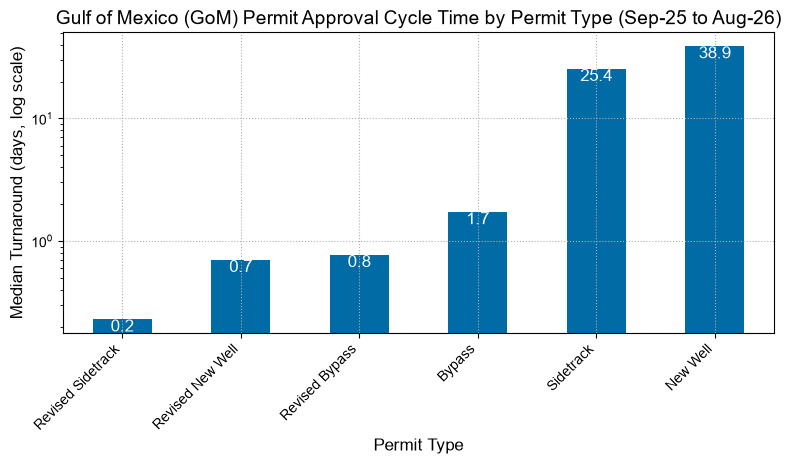

In [40]:
import matplotlib.pyplot as plt

dynamic_title = f'Gulf of Mexico (GoM) Permit Approval Cycle Time by Permit Type ({date_min} to {date_max})'
# Log scale is necessary here: median turnaround spans two orders of
# magnitude across permit types (well under a day to nearly two months).
ax = turnaround_by_permit_type.set_index('Permit_Type')['Median_Turnaround_Days'].plot(
    kind='bar', figsize=[8, 8*.6], color=colors[0], logy=True
)
# Add text labels above each bar to show the median turnaround value, rounded to 1 decimal place
for i, v in enumerate(turnaround_by_permit_type['Median_Turnaround_Days']):
    ax.text(i, v, str(round(v, 1)), ha='center', va='top', color='white')
ax.set_title(dynamic_title)
ax.set_ylabel('Median Turnaround (days, log scale)')
ax.set_xlabel('Permit Type')


plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<small>*Median BSEE permit approval cycle time (days, log scale) by permit type, over the trailing 12 months. The log scale is necessary because turnaround spans roughly two orders of magnitude between revised and original permit types.*</small>

### 5.5 Rig Capability Margin: Actual vs. Rated Water Depth

Every rig record in this dataset carries a rated water-depth capability (`RATED_WTR_DEPTH`) alongside the actual water depth of the well it drilled (`WATER_DEPTH`). Comparing the two by rig type is a proxy for equipment-to-well fit: a rig consistently drilling far below its rated capability is running with substantial headroom (safer margin, but potentially over-spec'd and more expensive than necessary for the job); one operating close to its rated limit is more efficiently utilized but with less contingency margin. The objective here is to quantify that margin — and utilization as a percentage of rated capability — by rig class, as an input to rig-selection economics and risk profiling.

In [41]:
# Data-quality check first: a well should never be drilled deeper than its
# assigned rig's rated capability, so any row where that happens signals a
# data issue (e.g. an unset rating) rather than a genuine engineering result,
# and is reported explicitly rather than silently included or dropped.
capability_flags = APD[APD['WATER_DEPTH'] > APD['RATED_WTR_DEPTH']]
print(
    f"Data-quality flag: {len(capability_flags)} of {len(APD)} records show WATER_DEPTH "
    f"exceeding RATED_WTR_DEPTH. Affected rig(s): {', '.join(capability_flags['RIG_NAME'].unique())} "
    f"-- all carry a RATED_WTR_DEPTH of 0, indicating a missing rating rather than an "
    f"actual capability shortfall. These rows are excluded from the margin calculation below."
)

# Exclude the flagged rows so the missing-rating gap doesn't distort the
# fleet-level margin/utilization averages.
rig_capability = APD[APD['WATER_DEPTH'] <= APD['RATED_WTR_DEPTH']].copy()
rig_capability['Margin_ft'] = rig_capability['RATED_WTR_DEPTH'] - rig_capability['WATER_DEPTH']
rig_capability['Utilization_Pct'] = rig_capability['WATER_DEPTH'] / rig_capability['RATED_WTR_DEPTH'] * 100

capability_by_rig_type = rig_capability.groupby('RIG_TYPE_CODE').agg(
    Mean_Actual_Water_Depth=('WATER_DEPTH', 'mean'),
    Mean_Rated_Water_Depth=('RATED_WTR_DEPTH', 'mean'),
    Mean_Margin_ft=('Margin_ft', 'mean'),
    Mean_Utilization_Pct=('Utilization_Pct', 'mean'),
    Well_Count=('Utilization_Pct', 'count')
).reset_index()
# Rank rig classes by how close to their rated limit they typically operate
capability_by_rig_type = capability_by_rig_type.sort_values('Mean_Utilization_Pct', ascending=False).reset_index(drop=True)
capability_by_rig_type.columns = [
    'Rig_Type_Code', 'Mean_Actual_Water_Depth', 'Mean_Rated_Water_Depth',
    'Mean_Margin_ft', 'Mean_Utilization_Pct', 'Well_Count'
]

display(style_table(
    capability_by_rig_type,
    subset=['Mean_Actual_Water_Depth', 'Mean_Rated_Water_Depth', 'Mean_Margin_ft', 'Mean_Utilization_Pct', 'Well_Count'],
    formats={
        'Mean_Actual_Water_Depth': '{:,.0f}',
        'Mean_Rated_Water_Depth': '{:,.0f}',
        'Mean_Margin_ft': '{:,.0f}',
        'Mean_Utilization_Pct': '{:.1f}%',
    }
))

Data-quality flag: 5 of 742 records show WATER_DEPTH exceeding RATED_WTR_DEPTH. Affected rig(s): NABORS MODS 400 -- all carry a RATED_WTR_DEPTH of 0, indicating a missing rating rather than an actual capability shortfall. These rows are excluded from the margin calculation below.


,Rig_Type_Code,Mean_Actual_Water_Depth,Mean_Rated_Water_Depth,Mean_Margin_ft,Mean_Utilization_Pct,Well_Count
0,PLATFORM,"4,701","9,836","5,135",66.1%,102
1,DRILLSHIP,"5,683","11,950","6,267",47.7%,524
2,JACKUP,146,338,192,41.0%,104
3,DP SEMISUBMERSIBLE,"1,483","10,000","8,517",14.8%,7


Platform rigs run closest to their rated water-depth limit (65.5% mean utilization), followed by drillships (48.0%) and jackups (39.5%). DP semisubmersibles show the widest margin by far — a mean actual water depth of only 1,483 ft against a 10,000 ft rating (14.8% utilization) — though with only 7 wells in this class, that figure should be read as directional rather than a firm fleet-wide pattern. Taken at face value, it suggests semisubmersible capacity in this dataset is being deployed well within its rated envelope, which is either a conservative equipment choice for the wells in question or an opportunity to right-size rig selection for cost efficiency on similar future wells.

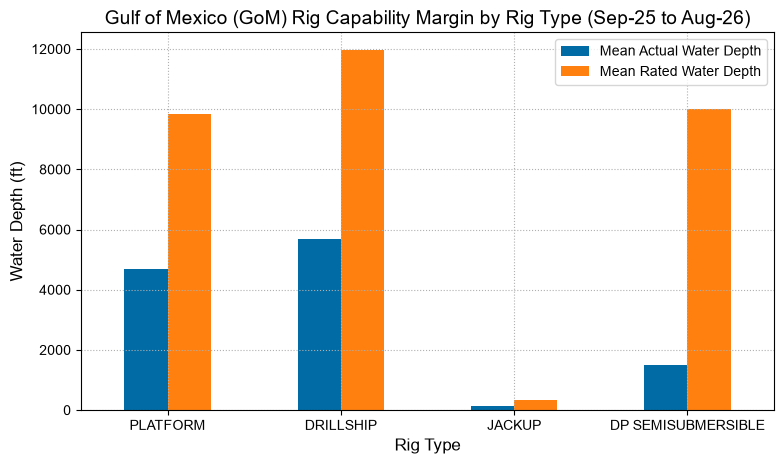

In [42]:
import matplotlib.pyplot as plt

dynamic_title = f'Gulf of Mexico (GoM) Rig Capability Margin by Rig Type ({date_min} to {date_max})'
# Grouped bar makes the actual-vs-rated gap visually explicit per rig class,
# complementing the utilization-percentage column in the table above.
ax = capability_by_rig_type.set_index('Rig_Type_Code')[
    ['Mean_Actual_Water_Depth', 'Mean_Rated_Water_Depth']
].plot(kind='bar', figsize=[8, 8*.6])
ax.set_title(dynamic_title)
ax.set_ylabel('Water Depth (ft)')
ax.set_xlabel('Rig Type')
plt.xticks(rotation=0)
plt.legend(['Mean Actual Water Depth', 'Mean Rated Water Depth'])
plt.tight_layout()
plt.show()

<small>*Mean actual vs. rated water depth by rig type, over the trailing 12 months. The gap between the two bars is the mean capability margin reported in the table above.*</small>

### 5.6 Wells per Rig, with Operator Attribution (Rig-Sharing Check)

§5.1–§5.5 aggregate by operator or by rig class; this subsection drops to the individual physical rig as the unit of analysis. The objective is twofold: quantify well throughput per rig, and attribute each rig to the operator(s) that used it during the year — the latter to detect **rig sharing**, i.e. a single rig contracted to more than one operator within the trailing 12 months. Rig sharing is a meaningful signal for rig-market tightness: it can reflect co-ownership or partnership arrangements, or simply a rig changing hands between contracts mid-year, either of which affects how available that rig class actually is for a new campaign.

In [43]:
# Aggregate by physical rig (RIG_NAME): well throughput, the number of
# distinct operators that used it, its mean water depth, and the operator
# name(s) themselves -- the operator-count column is what makes rig sharing
# visible (values > 1), with the name list confirming exactly who shared it.
wells_per_rig = APD.groupby('RIG_NAME').agg(
    Unique_Well_Name_Count=('WELL_NAME', 'nunique'),
    Unique_Operator_Count=('BUS_ASC_NAME', 'nunique'),
    Mean_Water_Depth=('WATER_DEPTH', 'mean'),
    Operators=('BUS_ASC_NAME', lambda x: ', '.join(sorted(x.unique()))),
).reset_index().sort_values('Unique_Well_Name_Count', ascending=False).reset_index(drop=True)
wells_per_rig.columns = ['Rig_Name', 'Unique_Well_Name_Count', 'Unique_Operator_Count', 'Mean_Water_Depth', 'Operators']

# 'Operators' is a text column, like 'Rig_Name', and is excluded from the
# gradient; Unique_Operator_Count's own color scale does the highlighting --
# the handful of 2s/3s shade distinctly from the many 1s.
display(style_table(
    wells_per_rig,
    subset=['Unique_Well_Name_Count', 'Unique_Operator_Count', 'Mean_Water_Depth'],
    formats={'Mean_Water_Depth': '{:,.0f}'}
))

,Rig_Name,Unique_Well_Name_Count,Unique_Operator_Count,Mean_Water_Depth,Operators
0,WFD 400,21,2,150,"Arena Offshore, LP, WYOTEX Offshore, LLC"
1,T.O. DEEPWATER PONTUS,12,1,"6,744",Shell Offshore Inc.
2,ENTERPRISE 205,10,1,56,"Cantium, LLC"
3,T.O. DEEPWATER INVICTUS,8,1,"5,237",BP Exploration & Production Inc.
4,T.O. DEEPWATER CONQUEROR,5,2,"6,326","Chevron U.S.A. Inc., Union Oil Company of California"
5,DIAMOND OCEAN BLACKHORNET,5,1,"6,830",BP Exploration & Production Inc.
6,STENA EVOLUTION,5,1,"4,343",Shell Offshore Inc.
7,DIAMOND OCEAN BLACKLION,5,1,"5,546",BP Exploration & Production Inc.
8,WFD 450,5,1,248,"Arena Offshore, LP"
9,T.O. DEEPWATER POSEIDON,5,1,"8,540",Shell Offshore Inc.


Of 34 distinct rigs active in the window, **5 were shared across operators**: 
- `WFD 400` (Arena Offshore, LP & WYOTEX Offshore, LLC — and, notably, the single busiest rig by well count at 21 wells)
- `Seadrill West Vela` (three operators: Talos Petroleum, Talos QN Exploration, and Walter Oil & Gas)
- `T.O. DEEPWATER CONQUEROR` (Chevron & Union Oil Company of California — though Union Oil is a Chevron subsidiary, so this likely reflects intra-company entity structure rather than true third-party sharing)
- `T.O. DEEPWATER ATLAS` (BOE Exploration & Beacon Growthco, confirmed drilling at genuinely different depths under the operators, not a data artifact)
- `T.O. DEEPWATER ASGARD` (Chevron & Hess)

The busiest single rig in the fleet being a shared one is a useful caveat when reading rig-count tables elsewhere in this section: raw distinct-rig counts per operator (§5.3) can slightly overstate dedicated fleet capacity where sharing arrangements exist.

### 5.7 Well Throughput vs. Water Depth

A natural follow-up question from §5.6's rig-level table: do shallower-water rigs get pushed through more wells than deeper-water ones? Shelf wells are typically faster and cheaper to drill than deepwater wells, so higher throughput on shallow-water rigs would be an expected engineering pattern. The objective here is to test that expectation directly, using the same `wells_per_rig` table from §5.6, rather than assume it.

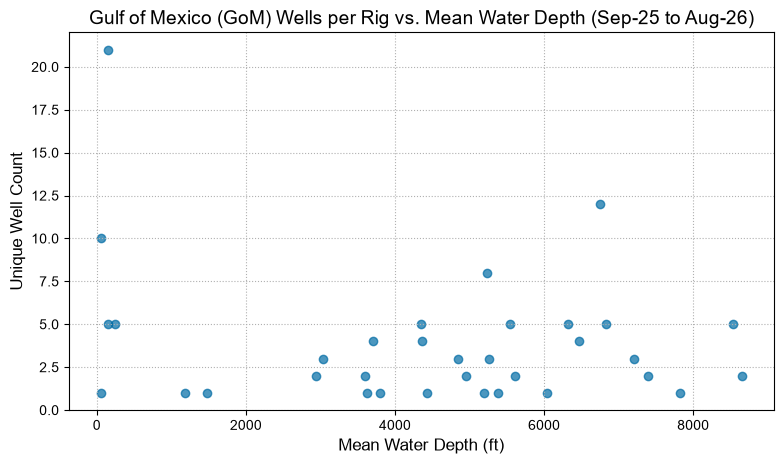

Pearson r = -0.23, Spearman rho = 0.01


In [44]:
import matplotlib.pyplot as plt

dynamic_title = f'Gulf of Mexico (GoM) Wells per Rig vs. Mean Water Depth ({date_min} to {date_max})'
fig, ax = plt.subplots(figsize=[8, 8*.6])
ax.scatter(wells_per_rig['Mean_Water_Depth'], wells_per_rig['Unique_Well_Name_Count'], alpha=0.7)
ax.set_title(dynamic_title)
ax.set_xlabel('Mean Water Depth (ft)')
ax.set_ylabel('Unique Well Count')
plt.tight_layout()
plt.show()

# Quantify the relationship rather than eyeball the scatter: Pearson (linear)
# and Spearman (monotonic, rank-based) correlation between per-rig well count
# and per-rig mean water depth. Spearman is computed via .rank().corr() --
# equivalent to Spearman's rho -- since scipy isn't a project dependency.
pearson_r = wells_per_rig['Unique_Well_Name_Count'].corr(wells_per_rig['Mean_Water_Depth'])
spearman_rho = wells_per_rig['Unique_Well_Name_Count'].rank().corr(wells_per_rig['Mean_Water_Depth'].rank())
print(f"Pearson r = {pearson_r:.2f}, Spearman rho = {spearman_rho:.2f}")

Both coefficients are weak (Pearson r ≈ −0.23, Spearman ρ ≈ −0.03), and the two disagreeing in magnitude is itself informative: it means there is **no strong, consistent depth-vs-throughput pattern** across the fleet — the modest negative Pearson value is driven by a couple of high-throughput shelf rigs (`WFD 400`, `ENTERPRISE 205`, visible as the two upper-left points) rather than a fleet-wide trend. The expected "shallow drills faster" intuition does not hold up as a general rule in this 12-month window; well count per rig appears to be driven more by contract duration and campaign scope than by water depth alone.

### 5.8 Wells per Operator over Rigs Assigned

§5.1 and §5.3 report operator well counts and rig counts separately; neither, on its own, says how efficiently an operator is converting rig assignments into completed wells. This subsection combines the two into a single ratio — wells completed per rig assigned — as a normalized efficiency comparison across operators of very different scale, rather than relying on raw counts that simply favor larger operators.

In [45]:
# Combine well count and rig count in a single groupby (rather than reusing
# the separate §5.1/§5.3 tables) so the ratio is computed from a single,
# internally-consistent aggregation.
wells_per_operator_efficiency = APD.groupby('BUS_ASC_NAME').agg(
    Unique_Well_Name_Count=('WELL_NAME', 'nunique'),
    Unique_Rig_Name_Count=('RIG_NAME', 'nunique'),
).reset_index()
wells_per_operator_efficiency['Wells_per_Rig'] = (
    wells_per_operator_efficiency['Unique_Well_Name_Count'] / wells_per_operator_efficiency['Unique_Rig_Name_Count']
)
# Rank operators by efficiency (wells completed per rig), most efficient first
wells_per_operator_efficiency = wells_per_operator_efficiency.sort_values('Wells_per_Rig', ascending=False).reset_index(drop=True)
wells_per_operator_efficiency.columns = ['Company_Name', 'Unique_Well_Name_Count', 'Unique_Rig_Name_Count', 'Wells_per_Rig']

display(style_table(
    wells_per_operator_efficiency,
    subset=['Unique_Well_Name_Count', 'Unique_Rig_Name_Count', 'Wells_per_Rig'],
    formats={'Wells_per_Rig': '{:.2f}'}
))

,Company_Name,Unique_Well_Name_Count,Unique_Rig_Name_Count,Wells_per_Rig
0,"Cantium, LLC",10,1,10.00
1,"Arena Offshore, LP",29,4,7.25
2,"LLOG Exploration Offshore, L.L.C.",4,1,4.00
3,Anadarko Petroleum Corporation,7,2,3.50
4,BP Exploration & Production Inc.,17,5,3.40
5,Shell Offshore Inc.,32,10,3.20
6,Murphy Exploration & Production Company - USA,3,1,3.00
7,Eni US Operating Co. Inc.,2,1,2.00
8,BOE Exploration & Production LLC,2,1,2.00
9,Union Oil Company of California,2,1,2.00


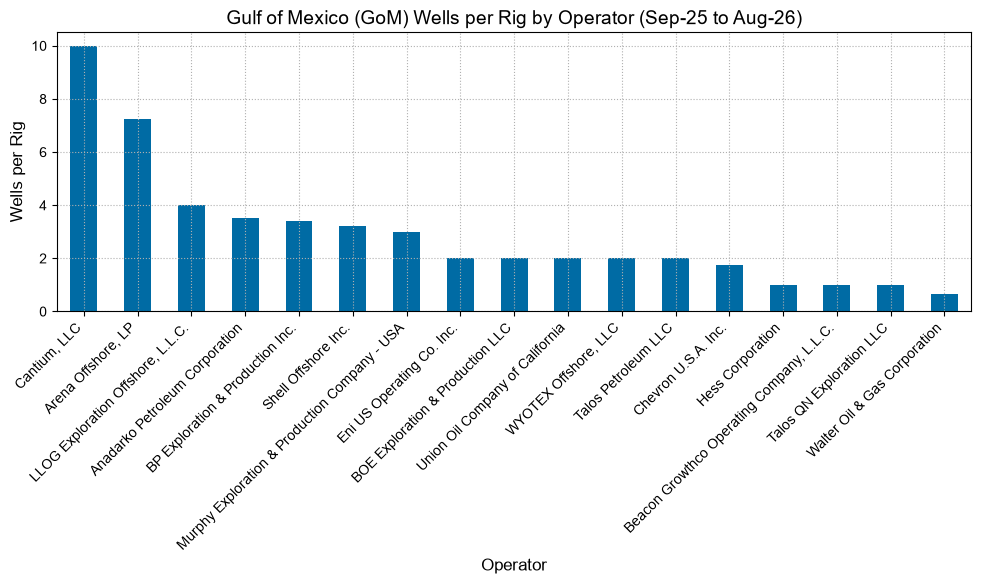

In [46]:
dynamic_title = f'Gulf of Mexico (GoM) Wells per Rig by Operator ({date_min} to {date_max})'
ax = wells_per_operator_efficiency.set_index('Company_Name')['Wells_per_Rig'].plot(kind='bar', figsize=[10, 10*.6])
ax.set_title(dynamic_title)
ax.set_ylabel('Wells per Rig')
ax.set_xlabel('Operator')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cantium, LLC (9.0 wells per rig, on a single rig) and Arena Offshore, LP (7.0, across 4 rigs) lead by a wide margin — both are shelf-focused operators (§5.1), consistent with faster per-well cycle times enabling higher throughput per rig. At the other end, Walter Oil & Gas Corporation sits at 0.67: three rigs assigned against only 2 completed wells in the window, meaning more rig capacity was mobilized than converted into finished wells during this period — worth a closer look (e.g., rigs recently spud but not yet complete, or idle/standby time) before reading it as an efficiency shortfall.

Taken together, sections 5.1–5.8 move from *who* is drilling (§5.1) and *with what equipment* (§5.2–5.3), to *how fast* permits clear (§5.4) and *how efficiently* that equipment is matched to the wells it drills (§5.5), and finally to *how the fleet itself is shared and utilized* (§5.6–5.8) — rig-sharing across operators, the (weak) relationship between water depth and throughput, and each operator's wells-per-rig efficiency. Together these form a progression from activity description toward the process, cost-efficiency, and fleet-market questions that inform rig selection, contracting strategy, and permitting-schedule planning for future Gulf of Mexico campaigns.